## Import Libraries


In [1]:
import os
import glob
import pandas as pd
from scipy import stats
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



### Set up Pyspark session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

25/06/16 16:53:02 WARN Utils: Your hostname, Xiao-Juns-Macbook-Pro-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.6 instead (on interface en0)
25/06/16 16:53:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/16 16:53:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Set up config


In [4]:
# Set up config
model_train_date_str = "2024-06-01"
train_test_period_months = 12
oot_period_months = 2
train_test_ratio = 0.8

config = {}
config["model_train_date_str"] = model_train_date_str
config["train_test_period_months"] = train_test_period_months
config["oot_period_months"] = oot_period_months
config["model_train_date"] = datetime.strptime(model_train_date_str, "%Y-%m-%d").date()
config["oot_end_date"] = config['model_train_date'] - timedelta(days=1)
config["oot_start_date"] = config['model_train_date'] - relativedelta(months=oot_period_months)
config["train_test_end_date"] = config["oot_start_date"] - timedelta(days=1)
config["train_test_start_date"] = config["oot_start_date"] - relativedelta(months=train_test_period_months)
config["train_test_ratio"] = train_test_ratio

pprint.pprint(config)

{'model_train_date': datetime.date(2024, 6, 1),
 'model_train_date_str': '2024-06-01',
 'oot_end_date': datetime.date(2024, 5, 31),
 'oot_period_months': 2,
 'oot_start_date': datetime.date(2024, 4, 1),
 'train_test_end_date': datetime.date(2024, 3, 31),
 'train_test_period_months': 12,
 'train_test_ratio': 0.8,
 'train_test_start_date': datetime.date(2023, 4, 1)}


In [5]:
print("=== Training Timeline ===")
print(f"Train/Test Period: {config['train_test_start_date']} to {config['train_test_end_date']}")
print(f"OOT Period: {config['oot_start_date']} to {config['oot_end_date']}")
print(f"Model Train Date: {config['model_train_date']}")

=== Training Timeline ===
Train/Test Period: 2023-04-01 to 2024-03-31
OOT Period: 2024-04-01 to 2024-05-31
Model Train Date: 2024-06-01


### Load Combined Label Store and Feature Store

In [6]:
# Read the Parquet file
combined_store = spark.read.parquet("datamart/gold/combined_store")

# Show schema and a few rows
combined_store.printSchema()
combined_store.show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- Age: integer (nullable = true)
 |-- occupation_developer: integer (nullable = true)
 |-- occupation_scientist: integer (nullable = true)
 |-- occupation_engineer: integer (nullable = true)
 |-- occupation_teacher: integer (nullable = true)
 |-- occupation_manager: integer (nullable = true)
 |-- occupation_enterpreneur: integer (nullable = true)
 |-- occupation_mechanic: integer (nullable = true)
 |-- occupation_musician: integer (nullable = true)
 |-- occupation_architect: integer (nullable = true)
 |-- occupation_writer: integer (nullable = true)
 |-- occupation_accountant: integer (nullable = true)
 |-- occupation_journalist: integer (nullable = true)
 |-- occupation_lawyer: integer (nullable = true)
 |-- occupation_doctor: integer (nullable = true)
 |-- occupation_media_manager: integer (nullable = true)
 |-- occupatio

+-----------+--------------------+-----------+-------------+---+--------------------+--------------------+-------------------+------------------+------------------+-----------------------+-------------------+-------------------+--------------------+-----------------+---------------------+---------------------+-----------------+-----------------+------------------------+------------------+-------------+---------------------+-----------------+---------------+-------------+-----------+-------------------+--------------------+----------------+------------------------+-------------------+-----------------------+---------------+----------------------+---------------+---------------+-------------------+-------------------------+------------------------+------------------------+--------------------------+-------------------------------------------------+--------------------------------------------------+-------------------------------------------------+-----------------------------------------

### Split Data into Train-Test-OOT

In [7]:
print("\n=== Using Combined Store ===")

# Convert filtered Spark DataFrame to Pandas
combined_df = combined_store.filter(
    (col("snapshot_date") >= config["train_test_start_date"]) & 
    (col("snapshot_date") <= config["oot_end_date"])
).toPandas()

print(f"Combined dataset: {len(combined_df)} rows")

# Ensure snapshot_date is in datetime format
combined_df["snapshot_date"] = pd.to_datetime(combined_df["snapshot_date"])

# If config values are still strings, convert them to datetime as well
config["train_test_start_date"] = pd.to_datetime(config["train_test_start_date"])
config["train_test_end_date"] = pd.to_datetime(config["train_test_end_date"])
config["oot_start_date"] = pd.to_datetime(config["oot_start_date"])
config["oot_end_date"] = pd.to_datetime(config["oot_end_date"])

# Train/Test dataset
train_test_pdf = combined_df[
    (combined_df["snapshot_date"] >= config["train_test_start_date"]) &
    (combined_df["snapshot_date"] <= config["train_test_end_date"])
]
print(f"Train/Test dataset: {len(train_test_pdf)} rows")

# Out-of-time (OOT) dataset
oot_pdf = combined_df[
    (combined_df["snapshot_date"] >= config["oot_start_date"]) &
    (combined_df["snapshot_date"] <= config["oot_end_date"])
]
print(f"OOT dataset: {len(oot_pdf)} rows")


=== Using Combined Store ===


Combined dataset: 6939 rows
Train/Test dataset: 5935 rows
OOT dataset: 1004 rows


In [8]:
train_test_pdf.columns

Index(['Customer_ID', 'Name', 'SSN', 'snapshot_date', 'Age',
       'occupation_developer', 'occupation_scientist', 'occupation_engineer',
       'occupation_teacher', 'occupation_manager', 'occupation_enterpreneur',
       'occupation_mechanic', 'occupation_musician', 'occupation_architect',
       'occupation_writer', 'occupation_accountant', 'occupation_journalist',
       'occupation_lawyer', 'occupation_doctor', 'occupation_media_manager',
       'occupation_unknown', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment',
       'Credit_Mix_None', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Payment_of_Min_Amount_NM', 'Payment_of_Min_Amount_

In [9]:
feature_cols = ['Age','occupation_developer', 'occupation_scientist', 'occupation_engineer',
       'occupation_teacher', 'occupation_manager', 'occupation_enterpreneur',
       'occupation_mechanic', 'occupation_musician', 'occupation_architect',
       'occupation_writer', 'occupation_accountant', 'occupation_journalist',
       'occupation_lawyer', 'occupation_doctor', 'occupation_media_manager',
       'occupation_unknown', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment',
       'Credit_Mix_None', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Payment_of_Min_Amount_NM', 'Payment_of_Min_Amount_None',
       'Payment_Behaviour_High_spent_Large_value_payments',
       'Payment_Behaviour_High_spent_Medium_value_payments',
       'Payment_Behaviour_High_spent_Small_value_payments',
       'Payment_Behaviour_Low_spent_Large_value_payments',
       'Payment_Behaviour_Low_spent_Medium_value_payments',
       'Payment_Behaviour_Low_spent_Small_value_payments',
       'Payment_Behaviour_None', 'Loan_Not_Specified',
       'Loan_debt_consolidation_loan', 'Loan_personal_loan',
       'Loan_payday_loan', 'Loan_mortgage_loan', 'Loan_credit_builder_loan',
       'Loan_auto_loan', 'Loan_home_equity_loan', 'Loan_student_loan',
       'disposable_income', 'DTI', 'num_active_loans',
       'credit_history_bucket_Short', 'credit_history_bucket_Medium',
       'credit_history_bucket_Long', 'credit_history_bucket_None',
       'credit_inquiries_bucket_Low', 'credit_inquiries_bucket_Medium',
       'credit_inquiries_bucket_High', 'credit_inquiries_bucket_None',
       'avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6',
       'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11',
       'avg_fe_12', 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16',
       'avg_fe_17', 'avg_fe_18', 'avg_fe_19', 'avg_fe_20'
]

X_oot = oot_pdf[feature_cols]
y_oot = oot_pdf["label"]

X_train, X_test, y_train, y_test = train_test_split(
    train_test_pdf[feature_cols], train_test_pdf["label"], 
    test_size= 1 - config["train_test_ratio"],
    random_state=88,     # Ensures reproducibility
    stratify=train_test_pdf["label"]           # Stratify based on the label column, equal representation in all the splits, handles class imbalance or when you have a lot of classes 
)


print('X_train', X_train.shape[0])
print('X_test', X_test.shape[0])
print('X_oot', X_oot.shape[0])
print('y_train', y_train.shape[0], round(y_train.mean(),2))
print('y_test', y_test.shape[0], round(y_test.mean(),2))
print('y_oot', y_oot.shape[0], round(y_oot.mean(),2))

X_train 4748
X_test 1187
X_oot 1004
y_train 4748 0.28
y_test 1187 0.28
y_oot 1004 0.29


In [10]:
X_train.describe()

,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,...,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20
count,4632.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.0,4748.000000,4748.000000,4748.000000,...,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000,4748.000000
mean,33.670337,0.063184,0.062763,0.062131,0.061289,0.061078,0.0,0.067818,0.058972,0.061710,...,99.453945,99.964038,100.777642,100.289494,99.996901,100.736851,99.813702,99.900104,99.883020,100.749687
std,10.795478,0.243320,0.242562,0.241420,0.239885,0.239499,0.0,0.251460,0.235597,0.240654,...,38.302939,38.614395,38.165969,39.245123,38.202898,38.779925,38.622041,39.580230,38.985167,39.240203
min,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,-115.000000,-105.666667,-71.250000,-93.250000,-52.000000,-109.333333,-65.666667,-107.000000,-115.000000,-89.333333
25%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,75.659091,75.801136,77.000000,75.650000,76.351190,76.400000,74.916667,75.138393,75.534091,76.267045
50%,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,100.000000,100.250000,100.809091,100.816667,99.727273,100.690476,99.773504,99.035714,100.240385,101.000000
75%,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,123.500000,124.593750,124.000000,125.000000,123.666667,125.200000,124.152597,124.833333,124.205556,125.000000
max,56.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,...,246.750000,293.666667,278.000000,311.333333,272.333333,280.666667,307.000000,306.333333,264.750000,253.666667


### Preprocess Data
- Applying StandardScaler to numerical variables (by right just continuous variables will do, but decided to scale both continuous AND discrete count variables because:
  - Some algorithm is sensitive to scale (SVM, KNN, Neural Networks, Logistic Regression)
  - Wide range of discrete values, e.g. some people have 1 card, others have 20+
  - Mixed with continuous features for consistency
- Perform imputation on columns with null values - Categorize features by imputation strategy
  - Median imputation/ mode imputation
- Handle outliers 


### Data Understanding - Missing Values 

In [11]:
# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Check for missing values first
print("Missing values per column:")
print(X_train.isnull().sum().sort_values(ascending=False))

Missing values per column:
Amount_invested_monthly                               217
Num_of_Loan                                           200
Num_Credit_Card                                       131
Age                                                   116
Interest_Rate                                         101
Changed_Credit_Limit                                  100
Num_of_Delayed_Payment                                 66
Num_Bank_Accounts                                      54
Loan_home_equity_loan                                   0
credit_inquiries_bucket_High                            0
Loan_payday_loan                                        0
Loan_mortgage_loan                                      0
Loan_credit_builder_loan                                0
Loan_auto_loan                                          0
credit_inquiries_bucket_Medium                          0
credit_inquiries_bucket_Low                             0
Loan_student_loan                            

### Data Understanding - Outliers 

In [12]:
# Categorize your numerical variables
continuous_vars = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Interest_Rate', 'Changed_Credit_Limit',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'disposable_income', 'DTI']

discrete_count_vars = [
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'num_active_loans']

engineered_features = ['avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6', 'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11',
    'avg_fe_12', 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16', 'avg_fe_17', 'avg_fe_18', 'avg_fe_19', 'avg_fe_20']

print("Variable categorization:")
print(f"Continuous variables: {len(continuous_vars)}")
print(f"Discrete count variables: {len(discrete_count_vars)}")
print(f"Engineered features: {len(engineered_features)}")

def detect_outliers_continuous(df, columns, method='iqr'):
    """Detect outliers in continuous variables using IQR or Z-score"""
    outlier_summary = {}
    
    for col in columns:
        if col in df.columns:
            data = df[col].dropna()
            
            if method == 'iqr':
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = data[(data < lower_bound) | (data > upper_bound)]
                
            elif method == 'zscore':
                z_scores = np.abs(stats.zscore(data))
                outliers = data[z_scores > 3]  # Z-score > 3 is outlier
                lower_bound = data.mean() - 3 * data.std()
                upper_bound = data.mean() + 3 * data.std()
            
            outlier_summary[col] = {
                'count': len(outliers),
                'percentage': (len(outliers) / len(data)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'min_outlier': outliers.min() if len(outliers) > 0 else None,
                'max_outlier': outliers.max() if len(outliers) > 0 else None
            }
    
    return outlier_summary

def detect_outliers_discrete(df, columns):
    """Detect outliers in discrete/count variables"""
    outlier_summary = {}
    
    for col in columns:
        if col in df.columns:
            data = df[col].dropna()
            
            # For discrete variables, use domain knowledge + statistical approach
            value_counts = data.value_counts().sort_index()
            
            # Method 1: Values that appear very rarely (< 1% of data)
            rare_threshold = len(data) * 0.01
            rare_values = value_counts[value_counts < rare_threshold].index.tolist()
            
            # Method 2: Values beyond reasonable business logic
            business_outliers = []
            if 'Num_Credit_Card' in col:
                business_outliers = data[data > 20].index.tolist()  # >20 credit cards unusual
            elif 'Num_Bank_Accounts' in col:
                business_outliers = data[data > 10].index.tolist()  # >10 bank accounts unusual
            elif 'Num_of_Loan' in col:
                business_outliers = data[data > 15].index.tolist()  # >15 loans unusual
            elif 'Delay_from_due_date' in col:
                business_outliers = data[data > 180].index.tolist()  # >6 months delay unusual
            
            # Method 3: Statistical outliers using modified Z-score for discrete data
            median = data.median()
            mad = np.median(np.abs(data - median))  # Median Absolute Deviation
            modified_z_scores = 0.6745 * (data - median) / mad if mad != 0 else np.zeros(len(data))
            statistical_outliers = data[np.abs(modified_z_scores) > 3.5].index.tolist()
            
            outlier_summary[col] = {
                'unique_values': data.nunique(),
                'rare_values': rare_values,
                'rare_count': len(rare_values),
                'business_outliers_count': len(business_outliers),
                'statistical_outliers_count': len(statistical_outliers),
                'min_value': data.min(),
                'max_value': data.max(),
                'median': data.median(),
                'distribution': value_counts.head(10).to_dict()
            }
    
    return outlier_summary

def analyze_engineered_features(df, columns):
    """Analyze engineered features for outliers"""
    outlier_summary = {}
    
    for col in columns:
        if col in df.columns:
            data = df[col].dropna()
            
            # Use IQR method for engineered features
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            
            outlier_summary[col] = {
                'count': len(outliers),
                'percentage': (len(outliers) / len(data)) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'skewness': stats.skew(data),
                'kurtosis': stats.kurtosis(data)
            }
    
    return outlier_summary

# Run outlier detection
print("\n" + "="*50)
print("CONTINUOUS VARIABLES OUTLIER ANALYSIS")
print("="*50)

continuous_outliers = detect_outliers_continuous(X_train, continuous_vars, method='iqr')
for var, info in continuous_outliers.items():
    print(f"\n{var}:")
    print(f"  Outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Range: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
    if info['min_outlier'] is not None:
        print(f"  Extreme values: {info['min_outlier']:.2f} to {info['max_outlier']:.2f}")

print("\n" + "="*50)
print("DISCRETE COUNT VARIABLES OUTLIER ANALYSIS")
print("="*50)

discrete_outliers = detect_outliers_discrete(X_train, discrete_count_vars)
for var, info in discrete_outliers.items():
    print(f"\n{var}:")
    print(f"  Unique values: {info['unique_values']}")
    print(f"  Range: {info['min_value']} to {info['max_value']} (median: {info['median']})")
    print(f"  Rare values: {info['rare_count']}")
    print(f"  Business outliers: {info['business_outliers_count']}")
    print(f"  Statistical outliers: {info['statistical_outliers_count']}")
    print(f"  Top values: {dict(list(info['distribution'].items())[:5])}")

print("\n" + "="*50)
print("ENGINEERED FEATURES OUTLIER ANALYSIS")
print("="*50)

engineered_outliers = analyze_engineered_features(X_train, engineered_features)
high_outlier_features = []
for var, info in engineered_outliers.items():
    if info['percentage'] > 5:  # Features with >5% outliers
        high_outlier_features.append(var)
    print(f"{var}: {info['count']} outliers ({info['percentage']:.2f}%), skew: {info['skewness']:.2f}")

print(f"\nEngineered features with >5% outliers: {high_outlier_features}")

# Summary recommendations
print("\n" + "="*50)
print("OUTLIER TREATMENT RECOMMENDATIONS")
print("="*50)

print("\n1. CONTINUOUS VARIABLES:")
for var, info in continuous_outliers.items():
    if info['percentage'] > 5:
        print(f"   {var}: {info['percentage']:.1f}% outliers - Consider capping or transformation")
    elif info['percentage'] > 1:
        print(f"   {var}: {info['percentage']:.1f}% outliers - Investigate further")
    else:
        print(f"   {var}: {info['percentage']:.1f}% outliers - Likely okay")

print("\n2. DISCRETE VARIABLES:")
for var, info in discrete_outliers.items():
    total_outliers = info['rare_count'] + info['business_outliers_count'] + info['statistical_outliers_count']
    if total_outliers > 0:
        print(f"   {var}: Review rare/extreme values - may need business logic validation")

print("\n3. ENGINEERED FEATURES:")
if high_outlier_features:
    print(f"   High outlier features: {high_outlier_features}")
    print("   Consider reviewing feature engineering logic")
else:
    print("   Engineered features look reasonable")

# Create visualization function
def plot_outliers(df, columns, var_type='continuous'):
    """Create visualization of outliers"""
    n_cols = min(3, len(columns))
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(columns[:9]):  # Limit to first 9 for visualization
        if col in df.columns:
            if var_type == 'continuous':
                df[col].hist(bins=50, ax=axes[i], alpha=0.7)
                axes[i].axvline(df[col].quantile(0.25), color='red', linestyle='--', alpha=0.5)
                axes[i].axvline(df[col].quantile(0.75), color='red', linestyle='--', alpha=0.5)
            else:
                df[col].value_counts().head(20).plot(kind='bar', ax=axes[i])
            axes[i].set_title(f'{col}')
            axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Uncomment to create visualizations
# print("\nCreating visualizations...")
# plot_outliers(X_train, continuous_vars[:9], 'continuous')
# plot_outliers(X_train, discrete_count_vars[:9], 'discrete')

Variable categorization:
Continuous variables: 12
Discrete count variables: 6
Engineered features: 20

CONTINUOUS VARIABLES OUTLIER ANALYSIS

Age:
  Outliers: 0 (0.00%)
  Range: [-0.50, 67.50]

Annual_Income:
  Outliers: 139 (2.93%)
  Range: [-59261.98, 150225.41]
  Extreme values: 150256.72 to 23834698.00

Monthly_Inhand_Salary:
  Outliers: 102 (2.15%)
  Range: [-4786.40, 12287.70]
  Extreme values: 12336.12 to 15136.70

Interest_Rate:
  Outliers: 0 (0.00%)
  Range: [-10.00, 38.00]

Changed_Credit_Limit:
  Outliers: 27 (0.58%)
  Range: [-9.29, 29.48]
  Extreme values: 29.53 to 36.97

Outstanding_Debt:
  Outliers: 251 (5.29%)
  Range: [-1491.54, 4034.92]
  Extreme values: 4041.90 to 4997.10

Credit_Utilization_Ratio:
  Outliers: 0 (0.00%)
  Range: [14.72, 49.76]

Total_EMI_per_month:
  Outliers: 342 (7.20%)
  Range: [-174.19, 375.94]
  Extreme values: 376.56 to 1000.00

Amount_invested_monthly:
  Outliers: 393 (8.67%)
  Range: [-174.25, 480.67]
  Extreme values: 481.01 to 1977.33

Mont

### Data Understanding - Multicollinearity 

VIF analysis cannot take null, therefore performing simple imputation first to check for multicollinearity 

In [17]:
# Columns with missing values
missing_cols = [
    'Amount_invested_monthly', 'Num_of_Loan', 'Num_Credit_Card', 'Age',
    'Interest_Rate', 'Changed_Credit_Limit', 'Num_of_Delayed_Payment', 'Num_Bank_Accounts'
]

# Discrete (count-like) features
discrete_cols_with_nulls = [
    'Num_of_Loan', 'Num_Credit_Card', 'Num_Bank_Accounts', 'Num_of_Delayed_Payment'
]

# Continuous (real-valued) features
continuous_cols_with_nulls = list(set(missing_cols) - set(discrete_cols_with_nulls))

# Create imputers
median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

# Make a copy of X_train for multicollinearity analysis
X_train_temp = X_train.copy()

# Apply median imputation to continuous features with nulls
X_train_temp[continuous_cols_with_nulls] = median_imputer.fit_transform(X_train_temp[continuous_cols_with_nulls])

# Apply mode imputation to discrete features with nulls
X_train_temp[discrete_cols_with_nulls] = mode_imputer.fit_transform(X_train_temp[discrete_cols_with_nulls])

In [18]:
def enhanced_multicollinearity_check(X, feature_names=None, feature_mapping=None, 
                                   original_df=None, vif_threshold=10, corr_threshold=0.8):
    """
    Enhanced multicollinearity analysis with better feature identification
    
    Parameters:
    - X: numpy array or dataframe of features
    - feature_names: list of feature names
    - feature_mapping: dict mapping feature indices to meaningful names
    - original_df: original dataframe before preprocessing (for reference)
    - vif_threshold: VIF threshold for flagging
    - corr_threshold: correlation threshold for flagging
    """
    
    # Convert to DataFrame if needed
    if isinstance(X, np.ndarray):
        if feature_names is None:
            feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=feature_names)
    else:
        df = X.copy()
        feature_names = df.columns.tolist()
    
    # Helper function to get meaningful name
    def get_meaningful_name(feature_name):
        if feature_mapping and feature_name.startswith('feature_'):
            idx = int(feature_name.split('_')[1])
            return feature_mapping.get(idx, feature_name)
        return feature_name
    
    print("=" * 70)
    print("ENHANCED MULTICOLLINEARITY ANALYSIS")
    print("=" * 70)
    print(f"Dataset shape: {df.shape}")
    print(f"VIF threshold: {vif_threshold}")
    print(f"Correlation threshold: {corr_threshold}")
    
    # Show feature mapping if provided
    if feature_mapping:
        print(f"\nFeature mapping provided for {len(feature_mapping)} features")
        print("Sample mappings:")
        for i, (idx, name) in enumerate(list(feature_mapping.items())[:5]):
            print(f"  feature_{idx} -> {name}")
        if len(feature_mapping) > 5:
            print(f"  ... and {len(feature_mapping) - 5} more")
    print()
    
    # 1. CORRELATION ANALYSIS
    print("1. CORRELATION ANALYSIS")
    print("-" * 30)
    
    corr_matrix = df.corr()
    
    # Find high correlations with meaningful names
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= corr_threshold:
                feat1_orig = corr_matrix.columns[i]
                feat2_orig = corr_matrix.columns[j]
                feat1_meaningful = get_meaningful_name(feat1_orig)
                feat2_meaningful = get_meaningful_name(feat2_orig)
                
                high_corr_pairs.append({
                    'feature1_orig': feat1_orig,
                    'feature2_orig': feat2_orig,
                    'feature1_meaningful': feat1_meaningful,
                    'feature2_meaningful': feat2_meaningful,
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    if high_corr_pairs:
        print(f"Found {len(high_corr_pairs)} highly correlated pairs (|r| >= {corr_threshold}):")
        for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
            print(f"  {pair['feature1_meaningful']} <-> {pair['feature2_meaningful']}")
            print(f"    Correlation: {pair['correlation']:.3f}")
            print(f"    Original names: {pair['feature1_orig']} <-> {pair['feature2_orig']}")
            print()
    else:
        print(f"No highly correlated pairs found (|r| >= {corr_threshold})")
    
    # 2. VIF ANALYSIS with meaningful names
    print("2. VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
    print("-" * 45)
    
    try:
        def calculate_vif(df_features):
            vif_values = []
            for i in range(df_features.shape[1]):
                X_vif = df_features.drop(df_features.columns[i], axis=1)
                y = df_features.iloc[:, i]
                
                reg = LinearRegression()
                reg.fit(X_vif, y)
                y_pred = reg.predict(X_vif)
                
                r2 = r2_score(y, y_pred)
                
                if r2 < 0.999:
                    vif = 1 / (1 - r2)
                else:
                    vif = float('inf')
                
                vif_values.append(vif)
            
            return vif_values
        
        vif_values = calculate_vif(df)
        vif_data = pd.DataFrame()
        vif_data["Feature_Original"] = feature_names
        vif_data["Feature_Meaningful"] = [get_meaningful_name(name) for name in feature_names]
        vif_data["VIF"] = vif_values
        vif_data = vif_data.sort_values('VIF', ascending=False)
        
        high_vif = vif_data[vif_data['VIF'] >= vif_threshold]
        
        print("VIF Results (sorted by VIF value):")
        print("Top 10 highest VIF values:")
        display_df = vif_data.head(10)[['Feature_Meaningful', 'Feature_Original', 'VIF']]
        print(display_df.to_string(index=False, float_format='%.2f'))
        print()
        
        if len(high_vif) > 0:
            print(f"⚠️  Features with VIF >= {vif_threshold} (multicollinearity concern):")
            for _, row in high_vif.iterrows():
                vif_val = row['VIF']
                if vif_val == float('inf'):
                    print(f"  {row['Feature_Meaningful']} (VIF: ∞)")
                else:
                    print(f"  {row['Feature_Meaningful']} (VIF: {vif_val:.2f})")
                print(f"    Original: {row['Feature_Original']}")
        else:
            print(f"✅ No features with concerning VIF values (all < {vif_threshold})")
            
    except Exception as e:
        print(f"VIF calculation failed: {str(e)}")
        vif_data = None
    
    # 3. DETAILED FEATURE ANALYSIS
    print("\n3. DETAILED FEATURE ANALYSIS")
    print("-" * 35)
    
    # Show statistics for problematic features
    if high_corr_pairs:
        print("Statistics for highly correlated features:")
        problematic_features = set()
        for pair in high_corr_pairs:
            problematic_features.add(pair['feature1_orig'])
            problematic_features.add(pair['feature2_orig'])
        
        for feat in sorted(problematic_features):
            meaningful_name = get_meaningful_name(feat)
            feat_stats = df[feat].describe()
            print(f"\n{meaningful_name} ({feat}):")
            print(f"  Mean: {feat_stats['mean']:.3f}, Std: {feat_stats['std']:.3f}")
            print(f"  Min: {feat_stats['min']:.3f}, Max: {feat_stats['max']:.3f}")
    
    # 4. RECOMMENDATIONS with meaningful names
    print("\n4. ENHANCED RECOMMENDATIONS")
    print("-" * 30)
    
    recommendations = []
    
    if high_corr_pairs:
        recommendations.append("🔸 Highly correlated features to investigate:")
        for pair in high_corr_pairs:
            recommendations.append(f"   Consider removing either:")
            recommendations.append(f"   - {pair['feature1_meaningful']} ({pair['feature1_orig']})")
            recommendations.append(f"   - {pair['feature2_meaningful']} ({pair['feature2_orig']})")
            recommendations.append(f"   Correlation: {pair['correlation']:.3f}")
            recommendations.append("")
    
    if vif_data is not None and len(high_vif) > 0:
        recommendations.append("🔸 High VIF features to consider removing:")
        for _, row in high_vif.iterrows():
            recommendations.append(f"   - {row['Feature_Meaningful']} ({row['Feature_Original']}) - VIF: {row['VIF']:.2f}")
    
    for rec in recommendations:
        print(rec)
    
    print("=" * 70)
    
    # Return enhanced results
    results = {
        'correlation_matrix': corr_matrix,
        'high_correlations': high_corr_pairs,
        'vif_data': vif_data,
        'high_vif_features': high_vif.to_dict('records') if vif_data is not None and len(high_vif) > 0 else [],
        'feature_mapping': feature_mapping
    }
    
    return results

# Example usage with feature mapping
def create_feature_mapping_example():
    """
    Example of how to create a feature mapping
    Adapt this based on your actual preprocessing pipeline
    """
    
    feature_names = [
        'Age', 'occupation_developer', 'occupation_scientist',
        'occupation_engineer', 'occupation_teacher', 'occupation_manager',
        'occupation_enterpreneur', 'occupation_mechanic', 'occupation_musician',
        'occupation_architect', 'occupation_writer', 'occupation_accountant',
        'occupation_journalist', 'occupation_lawyer', 'occupation_doctor',
        'occupation_media_manager', 'occupation_unknown', 'Annual_Income',
        'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
        'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
        'Changed_Credit_Limit', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
        'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
        'Num_of_Delayed_Payment', 'Credit_Mix_None', 'Credit_Mix_Good',
        'Credit_Mix_Standard', 'Payment_of_Min_Amount_Yes',
        'Payment_of_Min_Amount_No', 'Payment_of_Min_Amount_NM',
        'Payment_of_Min_Amount_None',
        'Payment_Behaviour_High_spent_Large_value_payments',
        'Payment_Behaviour_High_spent_Medium_value_payments',
        'Payment_Behaviour_High_spent_Small_value_payments',
        'Payment_Behaviour_Low_spent_Large_value_payments',
        'Payment_Behaviour_Low_spent_Medium_value_payments',
        'Payment_Behaviour_Low_spent_Small_value_payments',
        'Payment_Behaviour_None', 'Loan_Not_Specified',
        'Loan_debt_consolidation_loan', 'Loan_personal_loan',
        'Loan_payday_loan', 'Loan_mortgage_loan', 'Loan_credit_builder_loan',
        'Loan_auto_loan', 'Loan_home_equity_loan', 'Loan_student_loan',
        'disposable_income', 'DTI', 'num_active_loans',
        'credit_history_bucket_Short', 'credit_history_bucket_Medium',
        'credit_history_bucket_Long', 'credit_history_bucket_None',
        'credit_inquiries_bucket_Low', 'credit_inquiries_bucket_Medium',
        'credit_inquiries_bucket_High', 'credit_inquiries_bucket_None',
        'avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6',
        'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11',
        'avg_fe_12', 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16',
        'avg_fe_17', 'avg_fe_18', 'avg_fe_19', 'avg_fe_20'
    ]
    
    # Build the mapping
    feature_mapping = {i: name for i, name in enumerate(feature_names)}

    return feature_mapping

# Usage example:

# Create your feature mapping
feature_mapping = create_feature_mapping_example()

# Run enhanced analysis
results = enhanced_multicollinearity_check(
    X_train_temp, 
    feature_mapping=feature_mapping,
    vif_threshold=10, 
    corr_threshold=0.8
)


ENHANCED MULTICOLLINEARITY ANALYSIS
Dataset shape: (4748, 85)
VIF threshold: 10
Correlation threshold: 0.8

Feature mapping provided for 85 features
Sample mappings:
  feature_0 -> Age
  feature_1 -> occupation_developer
  feature_2 -> occupation_scientist
  feature_3 -> occupation_engineer
  feature_4 -> occupation_teacher
  ... and 80 more

1. CORRELATION ANALYSIS
------------------------------
Found 3 highly correlated pairs (|r| >= 0.8):
  Monthly_Inhand_Salary <-> disposable_income
    Correlation: 0.998
    Original names: Monthly_Inhand_Salary <-> disposable_income

  credit_history_bucket_Medium <-> credit_history_bucket_Long
    Correlation: -0.946
    Original names: credit_history_bucket_Medium <-> credit_history_bucket_Long

  Num_of_Loan <-> num_active_loans
    Correlation: 0.883
    Original names: Num_of_Loan <-> num_active_loans

2. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
---------------------------------------------
VIF Results (sorted by VIF value):
Top 10 highest V

Analyzing multicollinearity for 85 features in 4748 samples
Correlation threshold: 0.8
VIF threshold: 10


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

Plot saved as credit_score_multicollinearity_analysis.png


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


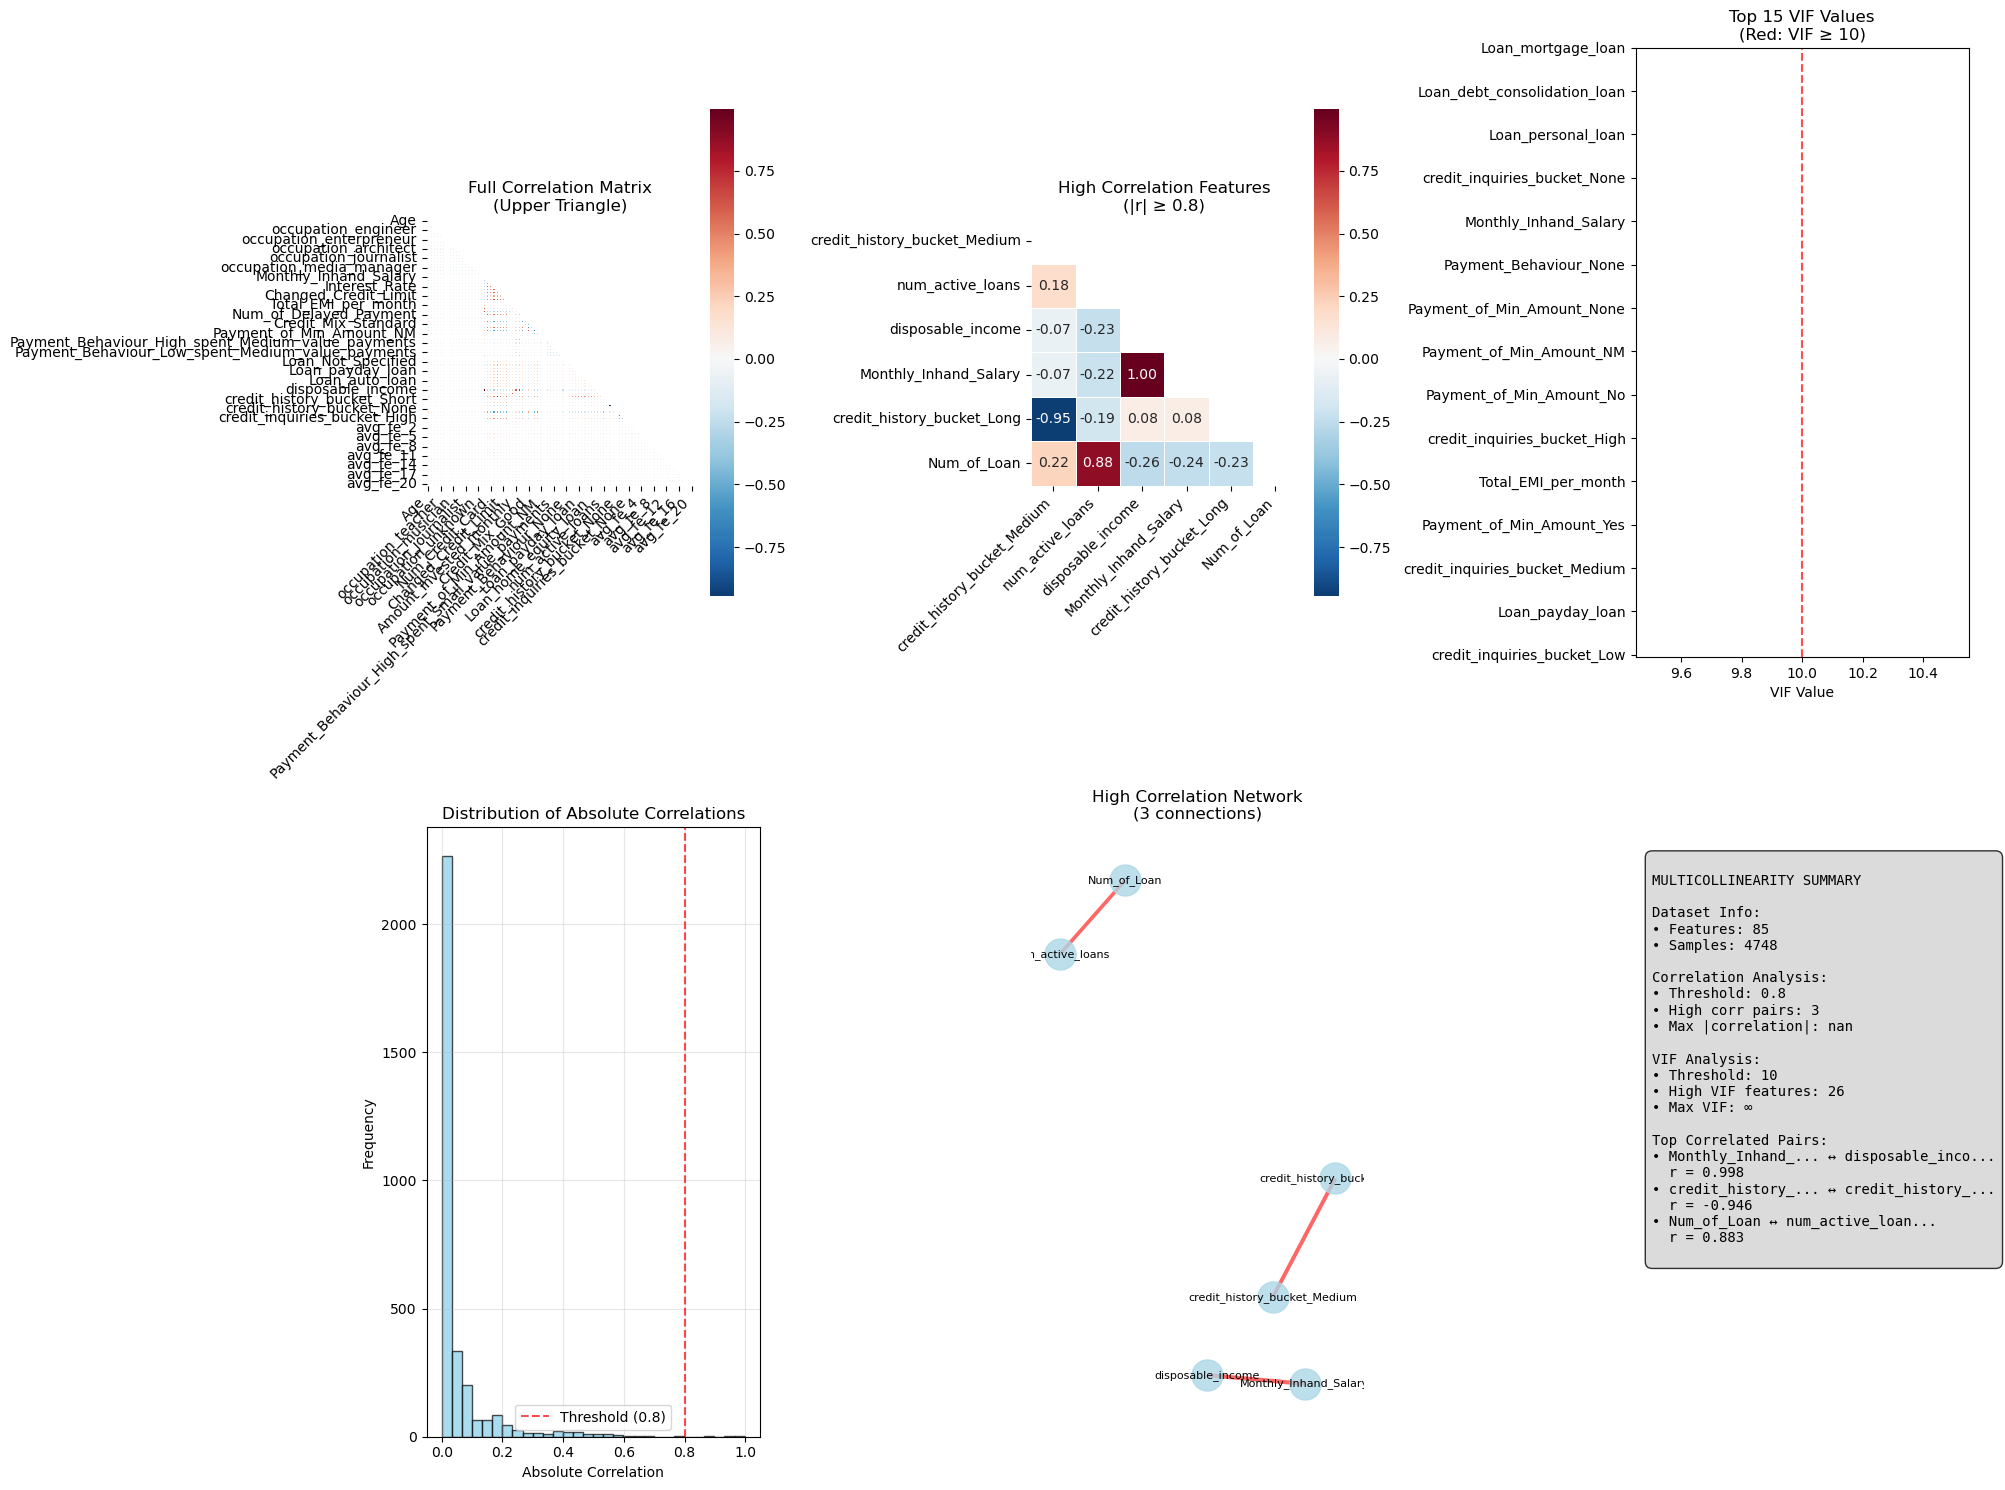


DETAILED MULTICOLLINEARITY RESULTS

🔍 HIGH CORRELATION PAIRS (|r| ≥ 0.8):
------------------------------------------------------------
 1. Monthly_Inhand_Salary ↔ disposable_income
     Correlation:   0.998

 2. credit_history_bucket_Medium ↔ credit_history_bucket_Long
     Correlation:  -0.946

 3. Num_of_Loan ↔ num_active_loans
     Correlation:   0.883


⚠️  HIGH VIF FEATURES (VIF ≥ 10):
--------------------------------------------------
• credit_inquiries_bucket_Low    VIF: ∞
• Loan_payday_loan               VIF: ∞
• credit_inquiries_bucket_Medium VIF: ∞
• Payment_of_Min_Amount_Yes      VIF: ∞
• Total_EMI_per_month            VIF: ∞
• credit_inquiries_bucket_High   VIF: ∞
• Payment_of_Min_Amount_No       VIF: ∞
• Payment_of_Min_Amount_NM       VIF: ∞
• Payment_of_Min_Amount_None     VIF: ∞
• Payment_Behaviour_None         VIF: ∞
• Monthly_Inhand_Salary          VIF: ∞
• credit_inquiries_bucket_None   VIF: ∞
• Loan_personal_loan             VIF: ∞
• Loan_debt_consolidation_loan   V

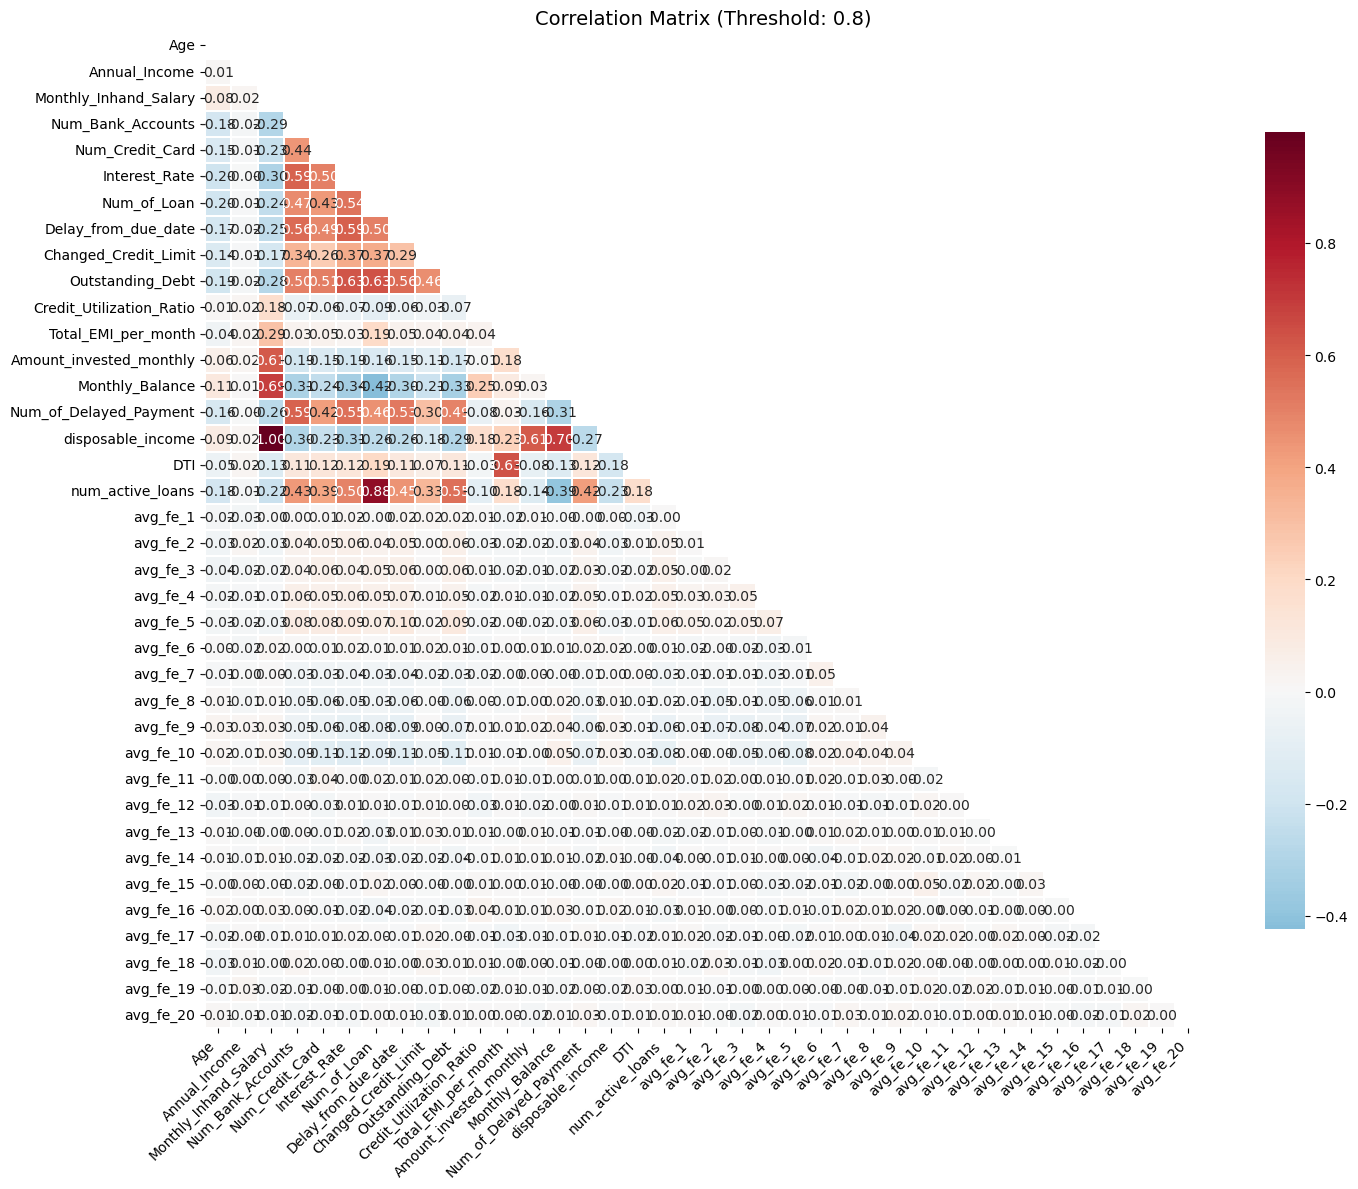


🔍 High correlation pairs (|r| ≥ 0.8):
• Monthly_Inhand_Salary ↔ disposable_income: 0.998
• Num_of_Loan ↔ num_active_loans: 0.883
Analyzing multicollinearity for 5 features in 4748 samples
Correlation threshold: 0.7
VIF threshold: 5


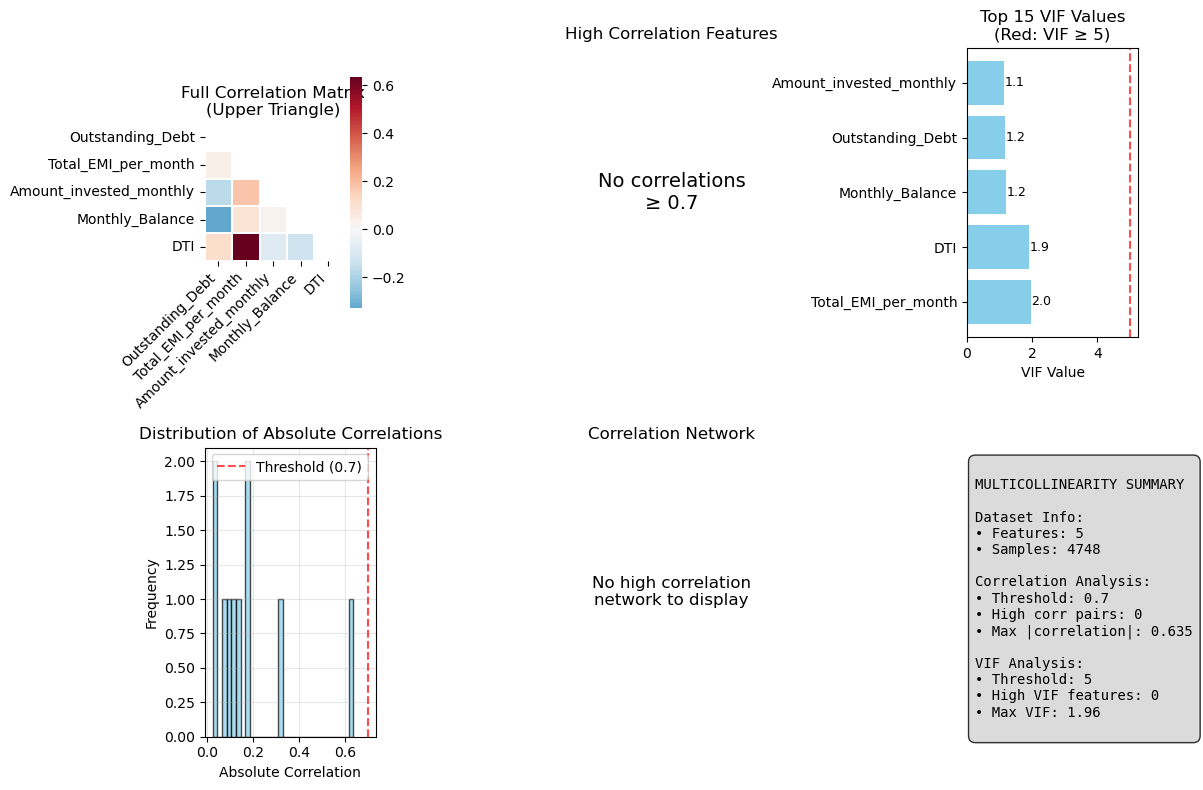


DETAILED MULTICOLLINEARITY RESULTS

✅ No highly correlated pairs found (threshold: 0.7)

✅ No high VIF features found (threshold: 5)


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

numerical_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
                 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',   
                 'Changed_Credit_Limit', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 
                 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 
                 'Num_of_Delayed_Payment', 'disposable_income', 'DTI', 'num_active_loans', 
                 'avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6', 
                 'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11', 'avg_fe_12', 
                 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16', 'avg_fe_17', 'avg_fe_18', 
                 'avg_fe_19', 'avg_fe_20']

def plot_multicollinearity_analysis(X, feature_names=None, corr_threshold=0.8, vif_threshold=10, 
                                   figsize=(20, 15), save_plots=False, plot_prefix="multicollinearity"):
    """
    Comprehensive multicollinearity visualization
    
    Parameters:
    - X: DataFrame or numpy array of features
    - feature_names: list of feature names (if X is numpy array)
    - corr_threshold: correlation threshold for highlighting
    - vif_threshold: VIF threshold for highlighting
    - figsize: figure size for plots
    - save_plots: whether to save plots
    - plot_prefix: prefix for saved plot files
    """
    
    # Convert to DataFrame if needed
    if isinstance(X, np.ndarray):
        if feature_names is None:
            feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=feature_names)
    else:
        df = X.copy()
        feature_names = df.columns.tolist()
    
    print(f"Analyzing multicollinearity for {df.shape[1]} features in {df.shape[0]} samples")
    print(f"Correlation threshold: {corr_threshold}")
    print(f"VIF threshold: {vif_threshold}")
    
    # Calculate correlation matrix
    corr_matrix = df.corr()
    
    # Calculate VIF
    def calculate_vif(df_features):
        vif_values = []
        feature_names = df_features.columns.tolist()
        
        for i in range(df_features.shape[1]):
            X_vif = df_features.drop(df_features.columns[i], axis=1)
            y = df_features.iloc[:, i]
            
            reg = LinearRegression()
            reg.fit(X_vif, y)
            y_pred = reg.predict(X_vif)
            
            r2 = r2_score(y, y_pred)
            
            if r2 < 0.999:
                vif = 1 / (1 - r2)
            else:
                vif = float('inf')
            
            vif_values.append(vif)
        
        return pd.DataFrame({
            'Feature': feature_names,
            'VIF': vif_values
        }).sort_values('VIF', ascending=False)
    
    try:
        vif_df = calculate_vif(df)
    except Exception as e:
        print(f"VIF calculation failed: {e}")
        vif_df = None
    
    # Find highly correlated pairs
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) >= corr_threshold:
                high_corr_pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_val
                })
    
    # Create subplots
    fig = plt.figure(figsize=figsize)
    
    # 1. Full Correlation Heatmap
    plt.subplot(2, 3, 1)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
                square=True, linewidths=0.1, cbar_kws={"shrink": .8})
    plt.title('Full Correlation Matrix\n(Upper Triangle)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # 2. High Correlation Heatmap (filtered)
    if high_corr_pairs:
        plt.subplot(2, 3, 2)
        # Get features involved in high correlations
        high_corr_features = set()
        for pair in high_corr_pairs:
            high_corr_features.add(pair['feature1'])
            high_corr_features.add(pair['feature2'])
        
        high_corr_features = list(high_corr_features)
        high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
        
        mask_high = np.triu(np.ones_like(high_corr_matrix, dtype=bool))
        sns.heatmap(high_corr_matrix, mask=mask_high, annot=True, cmap='RdBu_r', center=0,
                    square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
        plt.title(f'High Correlation Features\n(|r| ≥ {corr_threshold})', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    else:
        plt.subplot(2, 3, 2)
        plt.text(0.5, 0.5, f'No correlations\n≥ {corr_threshold}', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
        plt.title('High Correlation Features', fontsize=12)
        plt.axis('off')
    
    # 3. VIF Bar Plot
    if vif_df is not None:
        plt.subplot(2, 3, 3)
        # Show top 15 VIF values
        top_vif = vif_df.head(15)
        colors = ['red' if vif >= vif_threshold else 'skyblue' for vif in top_vif['VIF']]
        
        bars = plt.barh(range(len(top_vif)), top_vif['VIF'], color=colors)
        plt.yticks(range(len(top_vif)), top_vif['Feature'])
        plt.xlabel('VIF Value')
        plt.title(f'Top 15 VIF Values\n(Red: VIF ≥ {vif_threshold})', fontsize=12)
        plt.axvline(x=vif_threshold, color='red', linestyle='--', alpha=0.7)
        
        # Add value labels on bars
        for i, (bar, vif_val) in enumerate(zip(bars, top_vif['VIF'])):
            if vif_val == float('inf'):
                plt.text(bar.get_width() * 0.9, bar.get_y() + bar.get_height()/2, 
                        '∞', ha='center', va='center', fontweight='bold')
            else:
                plt.text(bar.get_width() + max(top_vif['VIF']) * 0.01, 
                        bar.get_y() + bar.get_height()/2, 
                        f'{vif_val:.1f}', ha='left', va='center', fontsize=9)
        
        plt.tight_layout()
    else:
        plt.subplot(2, 3, 3)
        plt.text(0.5, 0.5, 'VIF Calculation\nFailed', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
        plt.title('VIF Analysis', fontsize=12)
        plt.axis('off')
    
    # 4. Correlation Distribution
    plt.subplot(2, 3, 4)
    # Get upper triangle correlations (excluding diagonal)
    corr_values = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_values.append(abs(corr_matrix.iloc[i, j]))
    
    plt.hist(corr_values, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(x=corr_threshold, color='red', linestyle='--', alpha=0.7, 
                label=f'Threshold ({corr_threshold})')
    plt.xlabel('Absolute Correlation')
    plt.ylabel('Frequency')
    plt.title('Distribution of Absolute Correlations', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5. High Correlation Network (if applicable)
    plt.subplot(2, 3, 5)
    if high_corr_pairs:
        # Create a simple network visualization
        import networkx as nx
        
        G = nx.Graph()
        
        # Add edges with correlation as weight
        for pair in high_corr_pairs:
            G.add_edge(pair['feature1'], pair['feature2'], weight=abs(pair['correlation']))
        
        # Position nodes
        pos = nx.spring_layout(G, k=1, iterations=50)
        
        # Draw network
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                              node_size=500, alpha=0.8)
        
        # Draw edges with thickness based on correlation
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], 
                              alpha=0.6, edge_color='red')
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=8)
        
        plt.title(f'High Correlation Network\n({len(high_corr_pairs)} connections)', fontsize=12)
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, f'No high correlation\nnetwork to display', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Correlation Network', fontsize=12)
        plt.axis('off')
    
    # 6. Summary Statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Create summary text
    summary_text = f"""
MULTICOLLINEARITY SUMMARY

Dataset Info:
• Features: {df.shape[1]}
• Samples: {df.shape[0]}

Correlation Analysis:
• Threshold: {corr_threshold}
• High corr pairs: {len(high_corr_pairs)}
• Max |correlation|: {np.max(np.abs(corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)])):.3f}

VIF Analysis:
• Threshold: {vif_threshold}
"""
    
    if vif_df is not None:
        high_vif_count = len(vif_df[vif_df['VIF'] >= vif_threshold])
        max_vif = vif_df['VIF'].iloc[0] if len(vif_df) > 0 else 0
        summary_text += f"• High VIF features: {high_vif_count}\n"
        if max_vif != float('inf'):
            summary_text += f"• Max VIF: {max_vif:.2f}\n"
        else:
            summary_text += f"• Max VIF: ∞\n"
    
    if high_corr_pairs:
        summary_text += f"\nTop Correlated Pairs:\n"
        for i, pair in enumerate(sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)[:3]):
            feat1_short = pair['feature1'][:15] + '...' if len(pair['feature1']) > 15 else pair['feature1']
            feat2_short = pair['feature2'][:15] + '...' if len(pair['feature2']) > 15 else pair['feature2']
            summary_text += f"• {feat1_short} ↔ {feat2_short}\n  r = {pair['correlation']:.3f}\n"
    
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'{plot_prefix}_analysis.png', dpi=300, bbox_inches='tight')
        print(f"Plot saved as {plot_prefix}_analysis.png")
    
    plt.show()
    
    # Print detailed results
    print("\n" + "="*80)
    print("DETAILED MULTICOLLINEARITY RESULTS")
    print("="*80)
    
    if high_corr_pairs:
        print(f"\n🔍 HIGH CORRELATION PAIRS (|r| ≥ {corr_threshold}):")
        print("-" * 60)
        for i, pair in enumerate(sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)):
            print(f"{i+1:2d}. {pair['feature1']} ↔ {pair['feature2']}")
            print(f"     Correlation: {pair['correlation']:7.3f}")
            print()
    else:
        print(f"\n✅ No highly correlated pairs found (threshold: {corr_threshold})")
    
    if vif_df is not None:
        high_vif_features = vif_df[vif_df['VIF'] >= vif_threshold]
        if len(high_vif_features) > 0:
            print(f"\n⚠️  HIGH VIF FEATURES (VIF ≥ {vif_threshold}):")
            print("-" * 50)
            for _, row in high_vif_features.iterrows():
                if row['VIF'] == float('inf'):
                    print(f"• {row['Feature']:30s} VIF: ∞")
                else:
                    print(f"• {row['Feature']:30s} VIF: {row['VIF']:7.2f}")
        else:
            print(f"\n✅ No high VIF features found (threshold: {vif_threshold})")
    
    return {
        'correlation_matrix': corr_matrix,
        'high_corr_pairs': high_corr_pairs,
        'vif_df': vif_df,
        'summary': {
            'n_features': df.shape[1],
            'n_samples': df.shape[0],
            'n_high_corr_pairs': len(high_corr_pairs),
            'n_high_vif_features': len(vif_df[vif_df['VIF'] >= vif_threshold]) if vif_df is not None else 0
        }
    }

# Simplified version for quick analysis
def quick_correlation_plot(X, feature_names=None, corr_threshold=0.8, figsize=(12, 10)):
    """
    Quick correlation heatmap with highlighted high correlations
    """
    # Convert to DataFrame if needed
    if isinstance(X, np.ndarray):
        if feature_names is None:
            feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=feature_names)
    else:
        df = X.copy()
    
    # Calculate correlation matrix
    corr_matrix = df.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Set up the matplotlib figure
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.1, cbar_kws={"shrink": .8}, fmt='.2f')
    
    plt.title(f'Correlation Matrix (Threshold: {corr_threshold})', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Find and print high correlations
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= corr_threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i], 
                    corr_matrix.columns[j], 
                    corr_matrix.iloc[i, j]
                ))
    
    plt.tight_layout()
    plt.show()
    
    if high_corr_pairs:
        print(f"\n🔍 High correlation pairs (|r| ≥ {corr_threshold}):")
        for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"• {feat1} ↔ {feat2}: {corr_val:.3f}")
    else:
        print(f"\n✅ No high correlations found (threshold: {corr_threshold})")
    
    return high_corr_pairs

# Usage examples:

# Example 1: Full analysis with your reduced dataset
results = plot_multicollinearity_analysis(
    X_train_temp, 
    corr_threshold=0.8, 
    vif_threshold=10,
    figsize=(20, 15),
    save_plots=True,
    plot_prefix="credit_score_multicollinearity"
)

# Example 2: Quick correlation plot
high_corr_pairs = quick_correlation_plot(
    X_train_temp[numerical_cols], 
    corr_threshold=0.8,
    figsize=(15, 12)
)

# Example 3: Focus on specific feature groups
high_outlier_cols = ['Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'DTI']
results_high_outlier = plot_multicollinearity_analysis(
    X_train_temp[high_outlier_cols],
    corr_threshold=0.7,
    vif_threshold=5,
    figsize=(12, 8)
)

### Outlier Handling

In [15]:
# Custom outlier handling transformer
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, method='iqr', factor=1.5, cap_method='percentile', lower_percentile=1, upper_percentile=99):
        """
        Custom outlier handler
        
        Parameters:
        - method: 'iqr' for IQR method, 'percentile' for percentile capping
        - factor: IQR factor (default 1.5)
        - cap_method: 'percentile' or 'iqr' for capping method
        - lower_percentile/upper_percentile: percentiles for capping (1-99)
        """
        self.method = method
        self.factor = factor
        self.cap_method = cap_method
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.bounds_ = {}
    
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        for col_idx in range(X_df.shape[1]):
            col_data = X_df.iloc[:, col_idx]
            
            if self.cap_method == 'iqr':
                Q1 = col_data.quantile(0.25)
                Q3 = col_data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - self.factor * IQR
                upper_bound = Q3 + self.factor * IQR
            else:  # percentile method
                lower_bound = col_data.quantile(self.lower_percentile / 100)
                upper_bound = col_data.quantile(self.upper_percentile / 100)
            
            self.bounds_[col_idx] = (lower_bound, upper_bound)
        
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        for col_idx in range(X_df.shape[1]):
            if col_idx in self.bounds_:
                lower_bound, upper_bound = self.bounds_[col_idx]
                X_df.iloc[:, col_idx] = np.clip(X_df.iloc[:, col_idx], lower_bound, upper_bound)
        
        return X_df.values if not isinstance(X, pd.DataFrame) else X_df


### Skewness Handling

In [16]:
# Simple log transformation skewness handler
class LogSkewnessHandler(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5):
        """
        Simple skewness handler using log transformation
        
        Parameters:
        - threshold: skewness threshold above which to apply log transformation
        """
        self.threshold = threshold
        self.apply_transform_ = {}
        self.shift_values_ = {}
        
    def fit(self, X, y=None):
        from scipy import stats
        
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        for col_idx in range(X_df.shape[1]):
            col_data = X_df.iloc[:, col_idx].dropna()
            skewness = abs(stats.skew(col_data))
            
            if skewness > self.threshold:
                min_val = col_data.min()
                
                if min_val > 0:
                    # Can use log directly
                    self.apply_transform_[col_idx] = True
                    self.shift_values_[col_idx] = 0
                elif min_val >= 0:
                    # Use log1p for non-negative values (handles zeros)
                    self.apply_transform_[col_idx] = True
                    self.shift_values_[col_idx] = 0
                else:
                    # Shift to make all values positive, then log
                    self.apply_transform_[col_idx] = True
                    self.shift_values_[col_idx] = abs(min_val) + 1
            else:
                self.apply_transform_[col_idx] = False
                self.shift_values_[col_idx] = 0
        
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        for col_idx in range(X_df.shape[1]):
            if self.apply_transform_.get(col_idx, False):
                try:
                    shift = self.shift_values_[col_idx]
                    
                    if shift > 0:
                        # Shift values to make positive, then log
                        X_df.iloc[:, col_idx] = np.log(X_df.iloc[:, col_idx] + shift)
                    else:
                        # Use log1p for non-negative values, log for positive
                        min_val = X_df.iloc[:, col_idx].min()
                        if min_val >= 0:
                            X_df.iloc[:, col_idx] = np.log1p(X_df.iloc[:, col_idx])
                        else:
                            X_df.iloc[:, col_idx] = np.log(X_df.iloc[:, col_idx])
                            
                except Exception as e:
                    print(f"Warning: Log transform failed for column {col_idx}: {str(e)}")
                    # Keep original values if transformation fails
                    pass
        
        return X_df.values if not isinstance(X, pd.DataFrame) else X_df
    
    def inverse_transform(self, X):
        """
        Inverse transform to get back original scale
        """
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        for col_idx in range(X_df.shape[1]):
            if self.apply_transform_.get(col_idx, False):
                try:
                    shift = self.shift_values_[col_idx]
                    
                    if shift > 0:
                        # Reverse: exp then subtract shift
                        X_df.iloc[:, col_idx] = np.exp(X_df.iloc[:, col_idx]) - shift
                    else:
                        # Reverse log1p or log
                        if hasattr(self, '_used_log1p') and self._used_log1p.get(col_idx, False):
                            X_df.iloc[:, col_idx] = np.expm1(X_df.iloc[:, col_idx])
                        else:
                            X_df.iloc[:, col_idx] = np.exp(X_df.iloc[:, col_idx])
                            
                except Exception as e:
                    print(f"Warning: Inverse transform failed for column {col_idx}: {str(e)}")
                    pass
        
        return X_df.values if not isinstance(X, pd.DataFrame) else X_df

### Data Preprocessing after Train Test Split

In [20]:
# Define column categories based on outlier analysis
numerical_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
                 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',   
                 'Changed_Credit_Limit', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 
                 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 
                 'Num_of_Delayed_Payment', 'disposable_income', 'DTI', 'num_active_loans', 
                 'avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6', 
                 'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11', 'avg_fe_12', 
                 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16', 'avg_fe_17', 'avg_fe_18', 
                 'avg_fe_19', 'avg_fe_20']

# High VIF features to remove (based on multicollinearity analysis)
high_vif_features = [
    'Monthly_Inhand_Salary', 'credit_history_bucket_Medium', 'num_active_loans', 'credit_inquiries_bucket_Medium'
]

# Drop high VIF features from all datasets
X_train_reduced = X_train.drop(columns=high_vif_features, errors='ignore')
X_test_reduced = X_test.drop(columns=high_vif_features, errors='ignore')
X_oot_reduced = X_oot.drop(columns=high_vif_features, errors='ignore')

# Update numerical columns by removing the dropped features
numerical_cols_reduced = [col for col in numerical_cols if col not in high_vif_features]

# Get remaining engineered features (only the ones that weren't dropped)
engineered_features_reduced = [f'avg_fe_{i}' for i in range(1, 21) if f'avg_fe_{i}' not in high_vif_features]

# Get one-hot encoded columns (assuming you have all column names)
# You need to define feature_cols or get all columns from your dataset
all_cols = X_train.columns.tolist()  # Get all column names from your dataset
onehot_cols = [col for col in all_cols if col not in numerical_cols]

# Update one-hot encoded columns by removing dropped features
onehot_cols_reduced = [col for col in onehot_cols if col not in high_vif_features]

# Categorize features by outlier severity and business logic
# High outlier columns (>5% outliers) - need aggressive treatment
high_outlier_cols = ['Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 
                    'Monthly_Balance', 'DTI']

# Medium outlier columns (2-5% outliers) - moderate treatment  
# Note: Annual_Income was removed due to high VIF, so excluding it
medium_outlier_cols = ['Monthly_Inhand_Salary', 'disposable_income']

# Low/no outlier columns - minimal treatment
low_outlier_cols = ['Age', 'Interest_Rate', 'Changed_Credit_Limit', 'Credit_Utilization_Ratio']

# Count/discrete variables - business logic validation
count_features = ['Num_of_Loan', 'Num_Credit_Card', 'Num_of_Delayed_Payment', 'Num_Bank_Accounts',
                 'Delay_from_due_date', 'num_active_loans']

# Filter all feature categories to only include features that exist in reduced dataset
high_outlier_cols = [col for col in high_outlier_cols if col in numerical_cols_reduced]
medium_outlier_cols = [col for col in medium_outlier_cols if col in numerical_cols_reduced]
low_outlier_cols = [col for col in low_outlier_cols if col in numerical_cols_reduced]
count_features = [col for col in count_features if col in numerical_cols_reduced]

# Create preprocessing pipeline
# Note: You'll need to define OutlierHandler and LogSkewnessHandler classes
# or replace them with available sklearn transformers

preprocessor_robust = ColumnTransformer(
    transformers=[
        ('high_outlier_pipe', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('outlier_handler', OutlierHandler(cap_method='percentile', lower_percentile=1, upper_percentile=99)),
            ('skewness_handler', LogSkewnessHandler(threshold=0.5)),
            ('scaler', StandardScaler())
        ]), high_outlier_cols),

        ('medium_outlier_pipe', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('outlier_handler', OutlierHandler(cap_method='percentile', lower_percentile=2, upper_percentile=98)),
            ('skewness_handler', LogSkewnessHandler(threshold=0.5)),
            ('scaler', StandardScaler())
        ]), medium_outlier_cols),

        ('low_outlier_pipe', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('outlier_handler', OutlierHandler(cap_method='iqr', factor=2.0)),
            ('skewness_handler', LogSkewnessHandler(threshold=0.8)),
            ('scaler', StandardScaler())
        ]), low_outlier_cols),

        ('count_pipe', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('outlier_handler', OutlierHandler(cap_method='percentile', lower_percentile=0.5, upper_percentile=99.5)),
            ('scaler', StandardScaler())
        ]), count_features),

        ('engineered_pipe', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('outlier_handler', OutlierHandler(cap_method='iqr', factor=2.5)),
            ('scaler', StandardScaler())
        ]), engineered_features_reduced),

        ('passthrough', 'passthrough', onehot_cols_reduced)
    ])

# Fit and transform
print("Fitting preprocessing pipeline...")
print(f"Features going into pipeline:")
print(f"  - High outlier: {high_outlier_cols}")
print(f"  - Medium outlier: {medium_outlier_cols}")
print(f"  - Low outlier: {low_outlier_cols}")
print(f"  - Count features: {count_features}")
print(f"  - Engineered features: {engineered_features_reduced}")
print(f"  - One-hot encoded: {len(onehot_cols_reduced)} features")

X_train_processed = preprocessor_robust.fit_transform(X_train_reduced)
X_test_processed = preprocessor_robust.transform(X_test_reduced)
X_oot_processed = preprocessor_robust.transform(X_oot_reduced)

print('X_train_processed:', X_train_processed.shape)
print('X_test_processed:', X_test_processed.shape)
print('X_oot_processed:', X_oot_processed.shape)

Fitting preprocessing pipeline...
Features going into pipeline:
  - High outlier: ['Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'DTI']
  - Medium outlier: ['disposable_income']
  - Low outlier: ['Age', 'Interest_Rate', 'Changed_Credit_Limit', 'Credit_Utilization_Ratio']
  - Count features: ['Num_of_Loan', 'Num_Credit_Card', 'Num_of_Delayed_Payment', 'Num_Bank_Accounts', 'Delay_from_due_date']
  - Engineered features: ['avg_fe_1', 'avg_fe_2', 'avg_fe_3', 'avg_fe_4', 'avg_fe_5', 'avg_fe_6', 'avg_fe_7', 'avg_fe_8', 'avg_fe_9', 'avg_fe_10', 'avg_fe_11', 'avg_fe_12', 'avg_fe_13', 'avg_fe_14', 'avg_fe_15', 'avg_fe_16', 'avg_fe_17', 'avg_fe_18', 'avg_fe_19', 'avg_fe_20']
  - One-hot encoded: 45 features
X_train_processed: (4748, 80)
X_test_processed: (1187, 80)
X_oot_processed: (1004, 80)


In [22]:
# Show columns

X_train_processed

array([[ 1.21232867, -0.0498787 , -0.74043572, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.92242455,  0.06791144, -1.91044009, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.51998919,  1.02921104,  0.35757077, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.95422959, -0.58549207,  0.42001501, ...,  1.        ,
         0.        ,  0.        ],
       [-0.45782334,  0.66393059, -0.01179109, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44577289,  0.74022657,  1.58834004, ...,  1.        ,
         0.        ,  0.        ]])

In [23]:
# Function to check skewness before and after preprocessing
def analyze_skewness_reduction(original_data, processed_data, feature_names, threshold=0.5):
    """
    Analyze skewness before and after preprocessing
    """    
    print("\n" + "="*70)
    print("SKEWNESS ANALYSIS - BEFORE AND AFTER PREPROCESSING")
    print("="*70)
    
    original_df = pd.DataFrame(original_data, columns=feature_names)
    processed_df = pd.DataFrame(processed_data)
    
    results = []
    
    for i, col in enumerate(feature_names):
        if col in numerical_cols:
            # Original skewness
            orig_skew = stats.skew(original_df[col].dropna())
            
            # Find processed column index (approximate mapping)
            # This is a simplified mapping - you might need to adjust based on your exact pipeline structure
            proc_col_idx = None
            for j, pipe_cols in enumerate([high_outlier_cols, medium_outlier_cols, 
                                         low_outlier_cols, count_features, engineered_features]):
                if col in pipe_cols:
                    # Calculate approximate index in processed data
                    prev_cols = 0
                    for k in range(j):
                        prev_cols += len([high_outlier_cols, medium_outlier_cols, 
                                        low_outlier_cols, count_features, engineered_features][k])
                    proc_col_idx = prev_cols + pipe_cols.index(col)
                    break
            
            if proc_col_idx is not None and proc_col_idx < processed_df.shape[1]:
                proc_skew = stats.skew(processed_df.iloc[:, proc_col_idx].dropna())
                improvement = abs(orig_skew) - abs(proc_skew)
                
                status = "✓ Much Better" if abs(proc_skew) < 0.5 else \
                        "✓ Better" if improvement > 0.2 else \
                        "~ Similar" if abs(improvement) < 0.1 else \
                        "✗ Worse"
                
                results.append({
                    'Feature': col,
                    'Original_Skew': orig_skew,
                    'Processed_Skew': proc_skew,
                    'Improvement': improvement,
                    'Status': status
                })
                
                print(f"{col:25} | {orig_skew:6.2f} → {proc_skew:6.2f} | {status}")
    
    # Summary
    highly_skewed = sum(1 for r in results if abs(r['Processed_Skew']) > 1.0)
    moderately_skewed = sum(1 for r in results if 0.5 < abs(r['Processed_Skew']) <= 1.0)
    low_skewed = sum(1 for r in results if abs(r['Processed_Skew']) <= 0.5)
    
    print(f"\n{'='*70}")
    print(f"SUMMARY:")
    print(f"Still highly skewed (|skew| > 1.0): {highly_skewed}")
    print(f"Moderately skewed (0.5 < |skew| ≤ 1.0): {moderately_skewed}")
    print(f"Low skewness (|skew| ≤ 0.5): {low_skewed}")
    print(f"{'='*70}")
    
    return results

In [24]:
analyze_skewness_reduction(X_train[numerical_cols], X_train_processed, numerical_cols)


SKEWNESS ANALYSIS - BEFORE AND AFTER PREPROCESSING
Age                       |   0.17 →   0.17 | ✓ Much Better
Num_Bank_Accounts         |  -0.17 →  -0.19 | ✓ Much Better
Num_Credit_Card           |   0.22 →   0.24 | ✓ Much Better
Interest_Rate             |   0.48 →   0.50 | ✓ Much Better
Num_of_Loan               |   0.44 →   0.43 | ✓ Much Better
Delay_from_due_date       |   0.99 →   0.99 | ~ Similar
Changed_Credit_Limit      |   0.73 →   0.75 | ~ Similar
Outstanding_Debt          |   1.20 →  -0.99 | ✓ Better
Credit_Utilization_Ratio  |   0.04 →   0.04 | ✓ Much Better
Total_EMI_per_month       |   2.98 →  -1.09 | ✓ Better
Amount_invested_monthly   |   2.60 →   0.15 | ✓ Much Better
Monthly_Balance           |   1.56 →  -0.21 | ✓ Much Better
Num_of_Delayed_Payment    |  -0.16 →  -0.20 | ✓ Much Better
disposable_income         |   1.16 →  -0.13 | ✓ Much Better
DTI                       |  10.27 →   4.57 | ✓ Better
avg_fe_1                  |   0.08 →   0.08 | ✓ Much Better
avg_fe_2   

[{'Feature': 'Age',
  'Original_Skew': 0.1653597284170591,
  'Processed_Skew': 0.17199581556129082,
  'Improvement': -0.006636087144231723,
  'Status': '✓ Much Better'},
 {'Feature': 'Num_Bank_Accounts',
  'Original_Skew': -0.17180363771721982,
  'Processed_Skew': -0.19337886032601906,
  'Improvement': -0.021575222608799238,
  'Status': '✓ Much Better'},
 {'Feature': 'Num_Credit_Card',
  'Original_Skew': 0.2194240713187464,
  'Processed_Skew': 0.24295098580911098,
  'Improvement': -0.023526914490364592,
  'Status': '✓ Much Better'},
 {'Feature': 'Interest_Rate',
  'Original_Skew': 0.48218013575034446,
  'Processed_Skew': 0.49835195227161,
  'Improvement': -0.016171816521265536,
  'Status': '✓ Much Better'},
 {'Feature': 'Num_of_Loan',
  'Original_Skew': 0.4419564491095097,
  'Processed_Skew': 0.4279408584492593,
  'Improvement': 0.014015590660250432,
  'Status': '✓ Much Better'},
 {'Feature': 'Delay_from_due_date',
  'Original_Skew': 0.9928269296173718,
  'Processed_Skew': 0.9864317598

In [25]:
# Optional: Create a function to analyze outlier reduction
def analyze_outlier_reduction(original_data, processed_data, feature_names):
    """
    Analyze how many outliers were handled
    """
    print("\n" + "="*50)
    print("OUTLIER REDUCTION ANALYSIS")
    print("="*50)
    
    original_df = pd.DataFrame(original_data, columns=feature_names)
    processed_df = pd.DataFrame(processed_data)
    
    for i, col in enumerate(feature_names):
        if col in numerical_cols:  # Only analyze numerical columns
            # Calculate original outliers using IQR
            Q1_orig = original_df[col].quantile(0.25)
            Q3_orig = original_df[col].quantile(0.75)
            IQR_orig = Q3_orig - Q1_orig
            lower_bound = Q1_orig - 1.5 * IQR_orig
            upper_bound = Q3_orig + 1.5 * IQR_orig
            
            orig_outliers = ((original_df[col] < lower_bound) | 
                           (original_df[col] > upper_bound)).sum()
            
            # For processed data, check if any values are at the capping bounds
            # This is an approximation since we don't have the exact bounds used
            proc_col_idx = [j for j, pipe_cols in enumerate([
                high_outlier_cols, medium_outlier_cols, low_outlier_cols,
                count_features, engineered_features
            ]) if col in pipe_cols]
            
            if proc_col_idx:
                orig_pct = (orig_outliers / len(original_df)) * 100
                print(f"{col}: {orig_outliers} original outliers ({orig_pct:.1f}%)")

# Example usage (uncomment to run analysis):
analyze_outlier_reduction(X_train[numerical_cols], X_train_processed, numerical_cols)


OUTLIER REDUCTION ANALYSIS
Age: 0 original outliers (0.0%)
Num_Bank_Accounts: 0 original outliers (0.0%)
Num_Credit_Card: 0 original outliers (0.0%)
Interest_Rate: 0 original outliers (0.0%)
Num_of_Loan: 0 original outliers (0.0%)
Delay_from_due_date: 204 original outliers (4.3%)
Changed_Credit_Limit: 27 original outliers (0.6%)
Outstanding_Debt: 251 original outliers (5.3%)
Credit_Utilization_Ratio: 0 original outliers (0.0%)
Total_EMI_per_month: 342 original outliers (7.2%)
Amount_invested_monthly: 393 original outliers (8.3%)
Monthly_Balance: 328 original outliers (6.9%)
Num_of_Delayed_Payment: 0 original outliers (0.0%)
disposable_income: 114 original outliers (2.4%)
DTI: 328 original outliers (6.9%)
avg_fe_1: 105 original outliers (2.2%)
avg_fe_2: 113 original outliers (2.4%)
avg_fe_3: 111 original outliers (2.3%)
avg_fe_4: 69 original outliers (1.5%)
avg_fe_5: 95 original outliers (2.0%)
avg_fe_6: 104 original outliers (2.2%)
avg_fe_7: 79 original outliers (1.7%)
avg_fe_8: 85 or

### Visualize Feature Importance 

Total features after preprocessing: 80
Calculating Random Forest feature importance...
Calculating Logistic Regression feature importance...
Calculating Permutation importance...


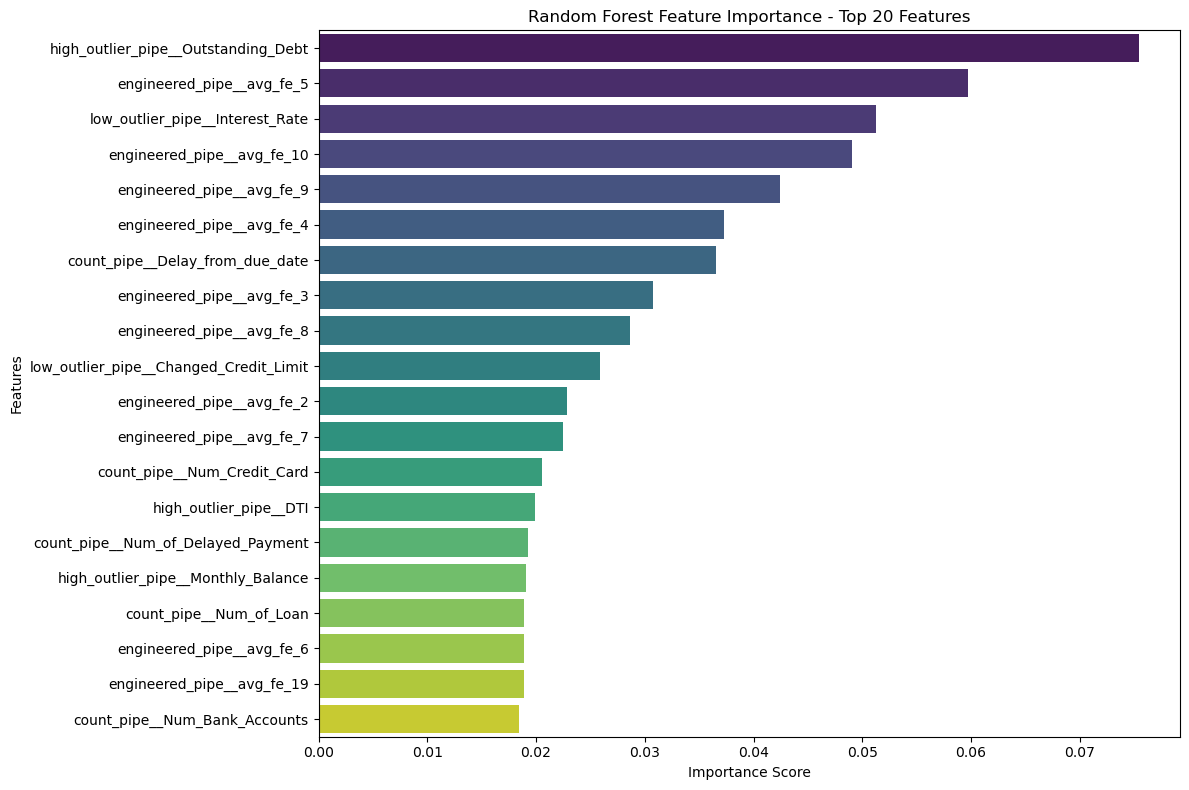

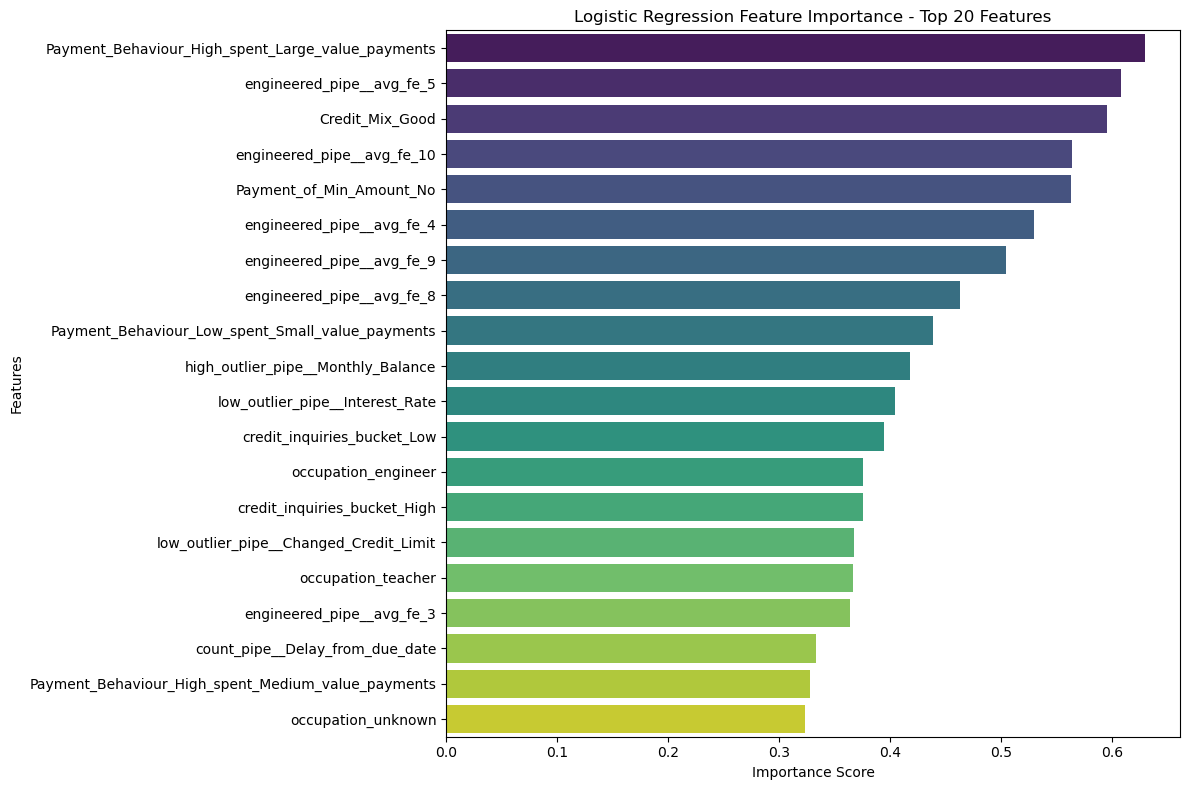

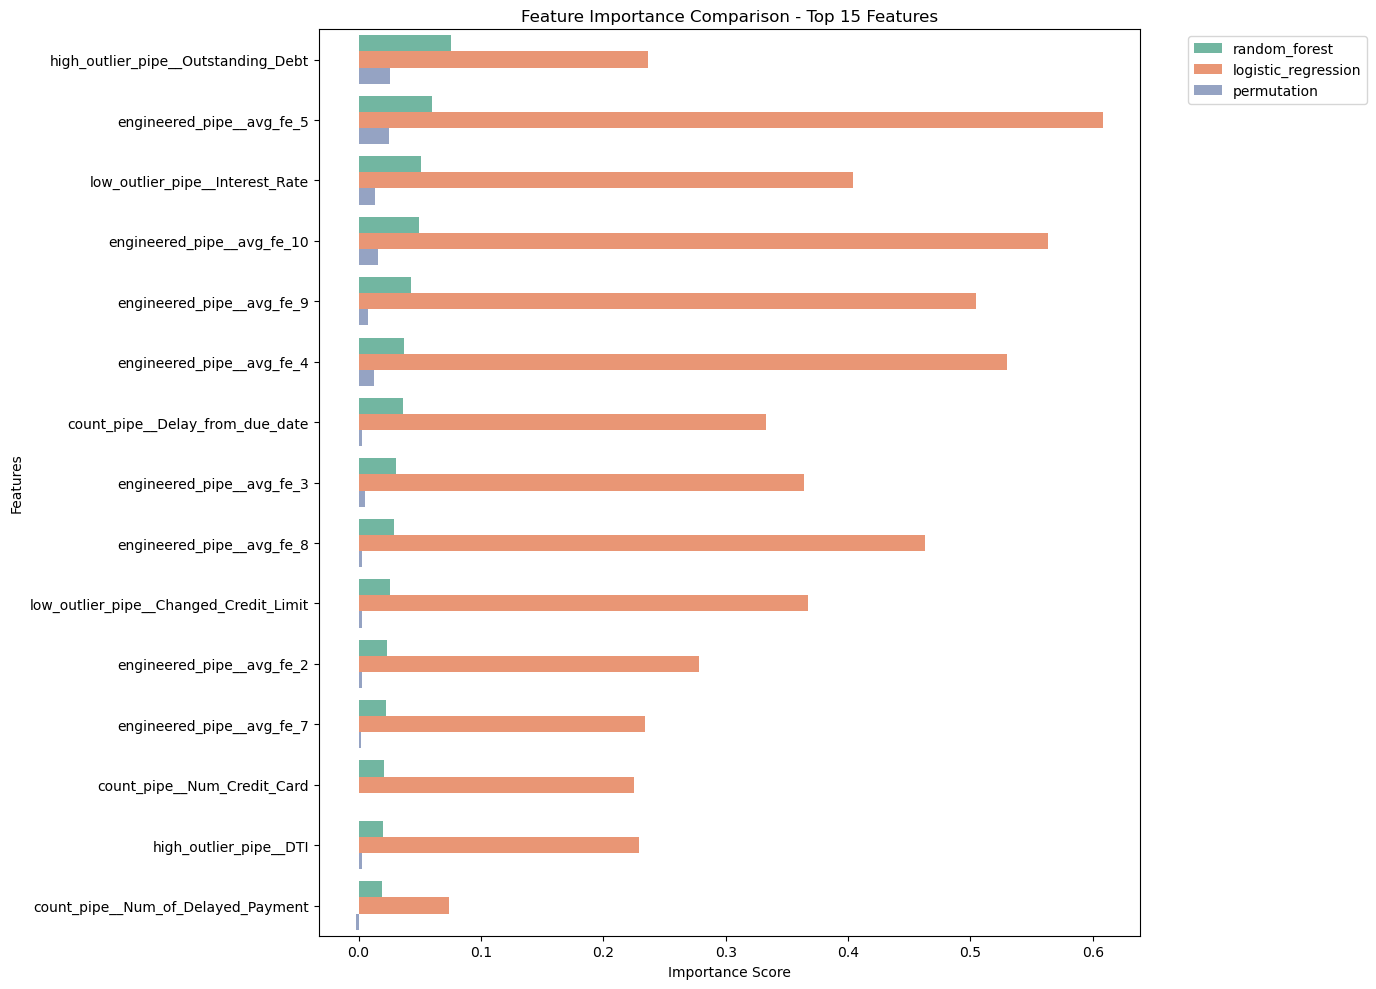

Feature Importance by Preprocessing Category:
high_outlier: Avg Importance = 0.0297, Features = 5
medium_outlier: Avg Importance = 0.0183, Features = 1
low_outlier: Avg Importance = 0.0275, Features = 4
count: Avg Importance = 0.0192, Features = 6
engineered: Avg Importance = 0.0252, Features = 20
onehot: Avg Importance = 0.0024, Features = 44

Top 20 Most Important Features:
                                   feature  importance
0      high_outlier_pipe__Outstanding_Debt    0.075444
19               engineered_pipe__avg_fe_5    0.059716
7          low_outlier_pipe__Interest_Rate    0.051255
24              engineered_pipe__avg_fe_10    0.049095
23               engineered_pipe__avg_fe_9    0.042420
18               engineered_pipe__avg_fe_4    0.037277
14         count_pipe__Delay_from_due_date    0.036505
17               engineered_pipe__avg_fe_3    0.030775
22               engineered_pipe__avg_fe_8    0.028650
8   low_outlier_pipe__Changed_Credit_Limit    0.025862
16              

In [31]:
# Feature Importance Analysis for Preprocessed Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Step 1: Get feature names after preprocessing
def get_feature_names_after_preprocessing(preprocessor, X_original):
    """
    Extract feature names after ColumnTransformer preprocessing
    """
    feature_names = []
    
    # Get feature names for each transformer
    for name, transformer, features in preprocessor.transformers_:
        if name != 'remainder':
            if hasattr(transformer, 'get_feature_names_out'):
                # For pipelines, get the final step's feature names
                if hasattr(transformer, 'steps'):
                    # Get feature names from the pipeline
                    temp_names = [f"{name}__{feat}" for feat in features]
                else:
                    temp_names = transformer.get_feature_names_out(features)
            else:
                # For passthrough or simple transformers
                if isinstance(features, str) and features == 'passthrough':
                    temp_names = features
                else:
                    temp_names = [f"{name}__{feat}" for feat in features]
            
            feature_names.extend(temp_names)
    
    return feature_names

# Get feature names (you'll need to run this with your fitted preprocessor)
try:
    feature_names = get_feature_names_after_preprocessing(preprocessor_robust, X_train_reduced)
    print(f"Total features after preprocessing: {len(feature_names)}")
except:
    # Fallback: create generic feature names
    n_features = X_train_processed.shape[1]
    feature_names = [f'feature_{i}' for i in range(n_features)]
    print(f"Using generic feature names for {n_features} features")

# Step 2: Train models for feature importance
def calculate_multiple_feature_importance(X_train, y_train, feature_names, X_test=None, y_test=None):
    """
    Calculate feature importance using multiple methods
    """
    results = {}
    
    # Method 1: Random Forest Feature Importance
    print("Calculating Random Forest feature importance...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_,
        'method': 'Random Forest'
    }).sort_values('importance', ascending=False)
    
    results['random_forest'] = {
        'model': rf_model,
        'importance_df': rf_importance,
        'score': rf_model.score(X_test, y_test) if X_test is not None else None
    }
    
    # Method 2: Logistic Regression Coefficients
    print("Calculating Logistic Regression feature importance...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train, y_train)
    
    # Use absolute values of coefficients for importance
    coef_importance = np.abs(lr_model.coef_[0])
    lr_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': coef_importance,
        'method': 'Logistic Regression'
    }).sort_values('importance', ascending=False)
    
    results['logistic_regression'] = {
        'model': lr_model,
        'importance_df': lr_importance,
        'score': lr_model.score(X_test, y_test) if X_test is not None else None
    }
    
    # Method 3: Permutation Importance (using Random Forest)
    if X_test is not None and y_test is not None:
        print("Calculating Permutation importance...")
        perm_importance = permutation_importance(
            rf_model, X_test, y_test, 
            n_repeats=10, random_state=42, n_jobs=-1
        )
        
        perm_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': perm_importance.importances_mean,
            'std': perm_importance.importances_std,
            'method': 'Permutation'
        }).sort_values('importance', ascending=False)
        
        results['permutation'] = {
            'importance_df': perm_importance_df
        }
    
    return results

# Step 3: Visualization functions
def plot_feature_importance(importance_df, title, top_n=20):
    """
    Plot feature importance
    """
    plt.figure(figsize=(12, 8))
    
    # Get top N features
    top_features = importance_df.head(top_n)
    
    # Create horizontal bar plot
    sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
    plt.title(f'{title} - Top {top_n} Features')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

def compare_feature_importance(results_dict, top_n=15):
    """
    Compare feature importance across different methods
    """
    # Combine all importance dataframes
    all_importance = []
    for method, result in results_dict.items():
        if 'importance_df' in result:
            df = result['importance_df'].copy()
            df['method'] = method
            all_importance.append(df)
    
    combined_df = pd.concat(all_importance, ignore_index=True)
    
    # Get top features from Random Forest (as baseline)
    rf_top_features = results_dict['random_forest']['importance_df'].head(top_n)['feature'].tolist()
    
    # Filter combined data to only include top features
    plot_data = combined_df[combined_df['feature'].isin(rf_top_features)]
    
    # Create comparison plot
    plt.figure(figsize=(14, 10))
    sns.barplot(data=plot_data, x='importance', y='feature', hue='method', palette='Set2')
    plt.title(f'Feature Importance Comparison - Top {top_n} Features')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Step 4: Feature importance analysis
def analyze_feature_importance_by_category(importance_df, feature_names):
    """
    Analyze feature importance by preprocessing category
    """
    categories = {
        'high_outlier': [],
        'medium_outlier': [],
        'low_outlier': [],
        'count': [],
        'engineered': [],
        'onehot': []
    }
    
    # Categorize features based on preprocessing pipeline names
    for feature in feature_names:
        if 'high_outlier' in feature:
            categories['high_outlier'].append(feature)
        elif 'medium_outlier' in feature:
            categories['medium_outlier'].append(feature)
        elif 'low_outlier' in feature:
            categories['low_outlier'].append(feature)
        elif 'count' in feature:
            categories['count'].append(feature)
        elif 'engineered' in feature:
            categories['engineered'].append(feature)
        else:
            categories['onehot'].append(feature)
    
    # Calculate average importance by category
    category_importance = {}
    for category, features in categories.items():
        if features:
            cat_importance = importance_df[importance_df['feature'].isin(features)]['importance'].mean()
            category_importance[category] = {
                'avg_importance': cat_importance,
                'num_features': len(features),
                'top_feature': importance_df[importance_df['feature'].isin(features)].iloc[0] if not importance_df[importance_df['feature'].isin(features)].empty else None
            }
    
    return category_importance

# Example usage (you'll need to provide y_train and optionally y_test):

# Assuming you have your target variable
# y_train = your_target_variable
# y_test = your_test_target_variable (optional)

# Calculate feature importance
results = calculate_multiple_feature_importance(
    X_train_processed, y_train, feature_names, 
    X_test_processed, y_test  # optional
)

# Plot individual method results
plot_feature_importance(results['random_forest']['importance_df'], 'Random Forest Feature Importance')
plot_feature_importance(results['logistic_regression']['importance_df'], 'Logistic Regression Feature Importance')

# Compare methods
compare_feature_importance(results)

# Analyze by category
category_analysis = analyze_feature_importance_by_category(
    results['random_forest']['importance_df'], feature_names
)

print("Feature Importance by Preprocessing Category:")
for category, info in category_analysis.items():
    if info:
        print(f"{category}: Avg Importance = {info['avg_importance']:.4f}, Features = {info['num_features']}")

# Get top 20 most important features
top_features = results['random_forest']['importance_df'].head(20)
print("\nTop 20 Most Important Features:")
print(top_features[['feature', 'importance']])


### Train Model - XGBoost


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV AUC score: 0.791

Train Performance:
  AUC: 0.9660 (Random = 0.5, Perfect = 1.0)
  GINI: 0.9319 (Random = 0, Perfect = 1.0)
  F1: 0.8465
  Lift at top 10%: 3.44x
  Precision at top 10%: 0.9789

Test Performance:
  AUC: 0.8989 (Random = 0.5, Perfect = 1.0)
  GINI: 0.7978 (Random = 0, Perfect = 1.0)
  F1: 0.6861
  Lift at top 10%: 3.22x
  Precision at top 10%: 0.9160

OOT Performance:
  AUC: 0.9270 (Random = 0.5, Perfect = 1.0)
  GINI: 0.8540 (Random = 0, Perfect = 1.0)
  F1: 0.7624
  Lift at top 10%: 3.25x
  Precision at top 10%: 0.9406

Performance Stability Analysis:
Train to Test AUC drop: 6.95%
Test to OOT AUC drop: -3.13%
Train to OOT AUC drop: 4.04%
⚠️  Significant overfitting detected (>5% drop from train to test)
✅ Mo

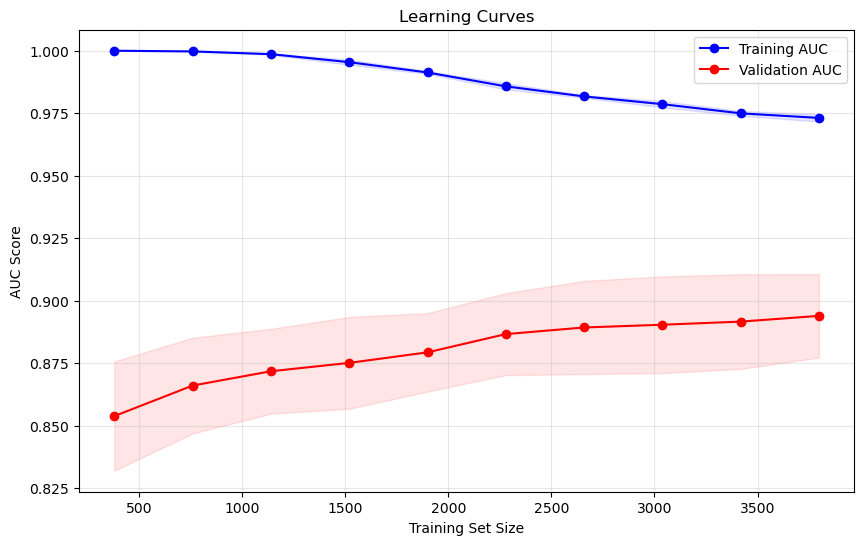

⚠️  High bias-variance gap suggests overfitting
   Try: increase regularization, reduce model complexity

BUSINESS-FRIENDLY METRIC EXPLANATIONS

📊 AUC (Area Under Curve):
   • Range: 0.5 (random) to 1.0 (perfect)
   • 0.7-0.8: Good model, 0.8-0.9: Excellent model
   • Business meaning: How well can we rank customers by risk?

📈 GINI Coefficient:
   • Range: 0 (random) to 1.0 (perfect)
   • Same information as AUC, just scaled: GINI = 2×AUC - 1
   • >0.4 is typically considered good in many industries

🎯 Lift at 10%:
   • How much better is the top 10% vs random selection?
   • 2.0x means top 10% has 2x the event rate of average
   • Higher lift = better targeting capability

✅ Precision at 10%:
   • What percentage of the top 10% are actually positive cases?
   • If base rate is 5%, precision of 20% at top 10% is very good
   • Directly translates to campaign success rate

MODEL IMPROVEMENT RECOMMENDATIONS

🔧 Based on your performance pattern:

1. OVERFITTING DETECTED:
   • Increase re

In [34]:
# Enhanced XGBoost Model with Better Evaluation and Interpretability
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, validation_curve, learning_curve
from sklearn.metrics import make_scorer
import xgboost as xgb
import shap

# Your existing hyperparameter tuning code (enhanced)
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=88)

# Expanded hyperparameter space for better exploration
param_dist = {
    'n_estimators': [50, 100, 200],  # Increased for potentially better performance
    'max_depth': [3, 4, 5, 6],       # Slightly deeper trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

# Enhanced random search
auc_scorer = make_scorer(roc_auc_score)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    scoring=auc_scorer,
    n_iter=50,  # Increased iterations for better exploration
    cv=5,       # 5-fold CV for more robust validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train_processed, y_train)
best_model = random_search.best_estimator_

print("Best parameters found:", random_search.best_params_)
print("Best CV AUC score:", round(random_search.best_score_, 4))

# Comprehensive Model Evaluation Function
def evaluate_model_comprehensive(model, X_sets, y_sets, set_names):
    """
    Comprehensive model evaluation across multiple datasets
    """
    results = {}
    
    for X, y, name in zip(X_sets, y_sets, set_names):
        # Predictions
        y_pred_proba = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)
        
        # Metrics
        auc = roc_auc_score(y, y_pred_proba)
        gini = 2 * auc - 1
        f1 = f1_score(y, y_pred)
        
        # Business-friendly interpretations
        lift_at_10 = calculate_lift_at_percentile(y, y_pred_proba, 10)
        precision_at_10 = calculate_precision_at_percentile(y, y_pred_proba, 10)
        
        results[name] = {
            'AUC': round(auc, 4),
            'GINI': round(gini, 4),
            'F1': round(f1, 4),
            'Lift@10%': round(lift_at_10, 2),
            'Precision@10%': round(precision_at_10, 4)
        }
        
        print(f"\n{name} Performance:")
        print(f"  AUC: {auc:.4f} (Random = 0.5, Perfect = 1.0)")
        print(f"  GINI: {gini:.4f} (Random = 0, Perfect = 1.0)")
        print(f"  F1: {f1:.4f}")
        print(f"  Lift at top 10%: {lift_at_10:.2f}x")
        print(f"  Precision at top 10%: {precision_at_10:.4f}")
    
    return results

def calculate_lift_at_percentile(y_true, y_scores, percentile):
    """Calculate lift at given percentile"""
    threshold = np.percentile(y_scores, 100 - percentile)
    top_percentile = y_scores >= threshold
    if np.sum(top_percentile) == 0:
        return 1.0
    
    lift = (np.sum(y_true[top_percentile]) / np.sum(top_percentile)) / np.mean(y_true)
    return lift

def calculate_precision_at_percentile(y_true, y_scores, percentile):
    """Calculate precision at given percentile"""
    threshold = np.percentile(y_scores, 100 - percentile)
    top_percentile = y_scores >= threshold
    if np.sum(top_percentile) == 0:
        return 0.0
    
    return np.sum(y_true[top_percentile]) / np.sum(top_percentile)

# Evaluate across all datasets
X_sets = [X_train_processed, X_test_processed, X_oot_processed]
y_sets = [y_train, y_test, y_oot]
set_names = ['Train', 'Test', 'OOT']

results = evaluate_model_comprehensive(best_model, X_sets, y_sets, set_names)

# Model Interpretability with SHAP
def explain_model_predictions(model, X_background, X_explain, feature_names=None):
    """
    Generate SHAP explanations for model predictions
    """
    # Create explainer
    explainer = shap.TreeExplainer(model)
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X_explain)
    
    # Feature importance plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False)
    plt.title("Feature Importance (SHAP Values)")
    plt.tight_layout()
    plt.show()
    
    return shap_values, explainer

# Performance Stability Analysis
def analyze_performance_stability(results):
    """
    Analyze performance degradation from train to OOT
    """
    train_auc = results['Train']['AUC']
    test_auc = results['Test']['AUC']
    oot_auc = results['OOT']['AUC']
    
    train_test_drop = (train_auc - test_auc) / train_auc * 100
    test_oot_drop = (test_auc - oot_auc) / test_auc * 100
    train_oot_drop = (train_auc - oot_auc) / train_auc * 100
    
    print(f"\nPerformance Stability Analysis:")
    print(f"Train to Test AUC drop: {train_test_drop:.2f}%")
    print(f"Test to OOT AUC drop: {test_oot_drop:.2f}%")
    print(f"Train to OOT AUC drop: {train_oot_drop:.2f}%")
    
    # Interpretation
    if train_test_drop > 5:
        print("⚠️  Significant overfitting detected (>5% drop from train to test)")
    elif train_test_drop < 1:
        print("✅ Model shows good generalization to test set")
    
    if test_oot_drop > 10:
        print("⚠️  High performance degradation on OOT data (>10% drop)")
        print("   Consider: temporal stability, data drift, or domain shift")
    elif test_oot_drop < 5:
        print("✅ Model maintains performance on OOT data")

analyze_performance_stability(results)

# Learning Curves to Diagnose Bias-Variance
def plot_learning_curves(model, X, y, cv=5):
    """
    Plot learning curves to diagnose overfitting/underfitting
    """
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='blue', label='Training AUC')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='red', label='Validation AUC')
    plt.fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                     np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1, color='blue')
    plt.fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                     np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.1, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('AUC Score')
    plt.title('Learning Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Interpretation
    final_train_auc = np.mean(train_scores[-1])
    final_val_auc = np.mean(val_scores[-1])
    gap = final_train_auc - final_val_auc
    
    if gap > 0.05:
        print("⚠️  High bias-variance gap suggests overfitting")
        print("   Try: increase regularization, reduce model complexity")
    elif final_val_auc < 0.65:
        print("⚠️  Low validation performance suggests underfitting")
        print("   Try: reduce regularization, increase model complexity, feature engineering")
    else:
        print("✅ Good bias-variance balance")

# Run learning curve analysis
plot_learning_curves(best_model, X_train_processed, y_train)

# Business-Friendly Metric Explanations
def explain_metrics_to_business():
    """
    Explain what the metrics mean in business terms
    """
    print("\n" + "="*60)
    print("BUSINESS-FRIENDLY METRIC EXPLANATIONS")
    print("="*60)
    
    print("\n📊 AUC (Area Under Curve):")
    print("   • Range: 0.5 (random) to 1.0 (perfect)")
    print("   • 0.7-0.8: Good model, 0.8-0.9: Excellent model")
    print("   • Business meaning: How well can we rank customers by risk?")
    
    print("\n📈 GINI Coefficient:")
    print("   • Range: 0 (random) to 1.0 (perfect)")
    print("   • Same information as AUC, just scaled: GINI = 2×AUC - 1")
    print("   • >0.4 is typically considered good in many industries")
    
    print("\n🎯 Lift at 10%:")
    print("   • How much better is the top 10% vs random selection?")
    print("   • 2.0x means top 10% has 2x the event rate of average")
    print("   • Higher lift = better targeting capability")
    
    print("\n✅ Precision at 10%:")
    print("   • What percentage of the top 10% are actually positive cases?")
    print("   • If base rate is 5%, precision of 20% at top 10% is very good")
    print("   • Directly translates to campaign success rate")

explain_metrics_to_business()

# Recommendations for Model Improvement
def improvement_recommendations(results):
    """
    Provide specific recommendations based on performance patterns
    """
    print("\n" + "="*60)
    print("MODEL IMPROVEMENT RECOMMENDATIONS")
    print("="*60)
    
    train_auc = results['Train']['AUC']
    test_auc = results['Test']['AUC']
    oot_auc = results['OOT']['AUC']
    
    print("\n🔧 Based on your performance pattern:")
    
    if train_auc - test_auc > 0.05:
        print("\n1. OVERFITTING DETECTED:")
        print("   • Increase regularization (reg_alpha, reg_lambda)")
        print("   • Reduce max_depth or increase min_child_weight")
        print("   • Use more cross-validation folds")
        print("   • Implement early stopping")
    
    if test_auc - oot_auc > 0.1:
        print("\n2. TEMPORAL/DOMAIN INSTABILITY:")
        print("   • Check for data drift between test and OOT periods")
        print("   • Consider time-based features or seasonal adjustments")
        print("   • Implement model retraining schedule")
        print("   • Use ensemble methods for robustness")
    
    if oot_auc < 0.65:
        print("\n3. OVERALL PERFORMANCE IMPROVEMENT:")
        print("   • Feature engineering: interactions, transformations")
        print("   • Try ensemble methods (combine XGB with other models)")
        print("   • Collect more relevant features")
        print("   • Check data quality and feature leakage")
    
    print("\n4. GENERAL BEST PRACTICES:")
    print("   • Use Bayesian optimization for hyperparameter tuning")
    print("   • Implement feature selection techniques")
    print("   • Monitor feature importance stability")
    print("   • Set up automated model monitoring")

improvement_recommendations(results)

# Additional Advanced Techniques
print("\n" + "="*60)
print("ADVANCED TECHNIQUES TO CONSIDER")
print("="*60)

advanced_techniques = """
🚀 Next Steps for Model Enhancement:

1. **Feature Engineering:**
   • Polynomial features and interactions
   • Target encoding for categorical variables
   • Time-based features (if applicable)
   • Feature binning and WOE transformations

2. **Advanced Hyperparameter Tuning:**
   • Bayesian Optimization (Optuna, Hyperopt)
   • Multi-objective optimization
   • Early stopping with validation sets

3. **Ensemble Methods:**
   • Blend XGBoost with LightGBM, CatBoost
   • Stacking with linear models
   • Voting classifiers

4. **Model Monitoring:**
   • PSI (Population Stability Index)
   • Feature drift detection
   • Performance decay monitoring
   • Automated retraining triggers

5. **Interpretability:**
   • LIME for local explanations
   • Partial dependence plots
   • Feature interaction analysis
   • Business rule extraction
"""

print(advanced_techniques)

In [35]:
# Define the XGBoost classifier
xgb = xgb.XGBClassifier(eval_metric='logloss', random_state=88)

# Define the hyperparameter space to search - non-exhaustive
param_dist = {
   'n_estimators': [50, 100, 200],  # Increased for potentially better performance
    'max_depth': [3, 4, 5, 6],       # Slightly deeper trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

# Create a scorer based on AUC score
auc_scorer = make_scorer(roc_auc_score)

# Set up the random search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    scoring=auc_scorer,
    n_iter=50,  # Number of iterations for random search
    cv=5,       # Number of folds in cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1   # Use all available cores, speed up the processing 
)

# Perform the random search
random_search.fit(X_train_processed, y_train)

# Output the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best AUC score: ", random_search.best_score_)

# Evaluate the model on the train set
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_train_processed)[:, 1]
train_auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC score: ", train_auc_score)

# Evaluate the model on the test set
best_model = random_search.best_estimator_ # use the best hyperparameter to get the best model 
y_pred_proba = best_model.predict_proba(X_test_processed)[:, 1]
test_auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC score: ", test_auc_score)

# Evaluate the model on the oot set
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_oot_processed)[:, 1]
oot_auc_score = roc_auc_score(y_oot, y_pred_proba)
print("OOT AUC score: ", oot_auc_score)

print("TRAIN GINI score: ", round(2*train_auc_score-1,3))
print("Test GINI score: ", round(2*test_auc_score-1,3))
print("OOT GINI score: ", round(2*oot_auc_score-1,3))

### GINI is another way of representing AUC. Can we try to convert AUC and F1 into something that people can understand?
### OOT1, OOT2, OOT3 will fare lower than the train and test. There will be deterioration for overfitted model. Model cannot
### generalize well to the unseen data. Low but stable performance could mean underfitting, therefore need to double check. 
### bias-variance trade-off, overfitting vs underfitting 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best AUC score:  0.7910351603941983
Train AUC score:  0.9659661821169765
Test AUC score:  0.8988751123842181
OOT AUC score:  0.9269771499351754
TRAIN GINI score:  0.932
Test GINI score:  0.798
OOT GINI score:  0.854


### Prepare Model Artefact to Save 

In [37]:
model_artefact = {}


# =============================================================================
# MODEL INFORMATION
# =============================================================================
model_artefact['model'] = best_model
model_artefact['model_version'] = "credit_model_XGB_" + config["model_train_date_str"].replace('-','_')
model_artefact['model_type'] = type(best_model).__name__
model_artefact['creation_timestamp'] = datetime.now().isoformat()

# =============================================================================
# PREPROCESSING & FEATURE INFORMATION
# =============================================================================
model_artefact['preprocessing_transformers'] = {}
model_artefact['preprocessing_transformers']['stdscaler'] = preprocessor_robust
model_artefact['preprocessing_transformers']['scaler_type'] = type(preprocessor_robust).__name__
    
# =============================================================================
# DATA INFORMATION & STATISTICS
# =============================================================================
model_artefact['data_dates'] = config
model_artefact['data_stats'] = {}
model_artefact['data_stats']['X_train'] = X_train.shape[0]
model_artefact['data_stats']['X_test'] = X_test.shape[0]
model_artefact['data_stats']['X_oot'] = X_oot.shape[0]
model_artefact['data_stats']['y_train'] = round(y_train.mean(),2)
model_artefact['data_stats']['y_test'] = round(y_test.mean(),2)
model_artefact['data_stats']['y_oot'] = round(y_oot.mean(),2)

# =============================================================================
# MODEL PERFORMANCE RESULTS
# =============================================================================
    
model_artefact['results'] = {}
model_artefact['results']['auc_train'] = train_auc_score
model_artefact['results']['auc_test'] = test_auc_score
model_artefact['results']['auc_oot'] = oot_auc_score
model_artefact['results']['gini_train'] = round(2*train_auc_score-1,3)
model_artefact['results']['gini_test'] = round(2*test_auc_score-1,3)
model_artefact['results']['gini_oot'] = round(2*oot_auc_score-1,3)

# =============================================================================
# HYPERPARAMETERS & MODEL CONFIGURATION
# =============================================================================
model_artefact['hp_params'] = random_search.best_params_


pprint.pprint(model_artefact)

{'creation_timestamp': '2025-06-16T19:42:44.506428',
 'data_dates': {'model_train_date': datetime.date(2024, 6, 1),
                'model_train_date_str': '2024-06-01',
                'oot_end_date': Timestamp('2024-05-31 00:00:00'),
                'oot_period_months': 2,
                'oot_start_date': Timestamp('2024-04-01 00:00:00'),
                'train_test_end_date': Timestamp('2024-03-31 00:00:00'),
                'train_test_period_months': 12,
                'train_test_ratio': 0.8,
                'train_test_start_date': Timestamp('2023-04-01 00:00:00')},
 'data_stats': {'X_oot': 1004,
                'X_test': 1187,
                'X_train': 4748,
                'y_oot': 0.29,
                'y_test': 0.28,
                'y_train': 0.28},
 'hp_params': {'colsample_bytree': 0.8,
               'gamma': 0.2,
               'learning_rate': 0.1,
               'max_depth': 3,
               'min_child_weight': 1,
               'n_estimators': 200,
              

### Save Artefact to Model Bank

In [38]:
# create model_bank dir
model_bank_directory = "model_bank/"

if not os.path.exists(model_bank_directory):
    os.makedirs(model_bank_directory)

In [39]:
# Full path to the file
file_path = os.path.join(model_bank_directory, model_artefact['model_version'] + '.pkl')

# Write the model to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(model_artefact, file)

print(f"Model saved to {file_path}")

Model saved to model_bank/credit_model_XGB_2024_06_01.pkl


### Test Load Pickle and Make Model Inference 

In [40]:
# Load the model from the pickle file
with open(file_path, 'rb') as file:
    loaded_model_artefact = pickle.load(file)

y_pred_proba = loaded_model_artefact['model'].predict_proba(X_oot_processed)[:, 1]
oot_auc_score = roc_auc_score(y_oot, y_pred_proba)
print("OOT AUC score: ", oot_auc_score)

print("Model loaded successfully!")

OOT AUC score:  0.9269771499351754
Model loaded successfully!
